# V1 Experiment Evaluation

Auto-discovering evaluation notebook for the v1 experimental framework.
Analyzes results across 5 models × 4 context conditions (c0-c3).

In [77]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Auto-discover model folders
V1_DIR = Path(".").resolve()
MODEL_DIRS = [d for d in V1_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")]

# Add AEC_new_def experiment directories (updated AEC definition)
AEC_NEW_DEF_DIR = V1_DIR.parent / "AEC_new_def"
if AEC_NEW_DEF_DIR.exists():
    for subdir in AEC_NEW_DEF_DIR.iterdir():
        if subdir.is_dir() and not subdir.name.startswith("."):
            MODEL_DIRS.append(subdir)
    print(f"Added AEC_new_def dirs: {[d.name for d in AEC_NEW_DEF_DIR.iterdir() if d.is_dir()]}")

print(f"Discovered model folders: {[d.name for d in MODEL_DIRS]}")

Added AEC_new_def dirs: ['ministral_8b', 'gpt_5_2_openai', 'mistral_medium']
Discovered model folders: ['ministral_8b', 'gpt_5_2_openai', 'mistral_medium', 'ministral_8b', 'gpt_5_2_openai', 'mistral_medium']


In [78]:
# Style configuration for thesis-quality visualizations
plt.rcParams.update({"figure.dpi": 150, "axes.titlesize": 14, "axes.labelsize": 12})
sns.set_theme(style="whitegrid", palette="colorblind")
CONTEXT_COLORS = {"c0": "#1f77b4", "c1": "#ff7f0e", "c2": "#2ca02c", "c3": "#d62728"}

In [79]:
def load_results(model_dir: Path) -> list[dict]:
    """Load all JSON result files from a model directory."""
    results = []
    for json_file in model_dir.glob("*.json"):
        with open(json_file) as f:
            data = json.load(f)
            data["_file"] = json_file.name
            data["_model_dir"] = model_dir.name
            results.append(data)
    return results

# Load all results
all_results = []
for model_dir in MODEL_DIRS:
    all_results.extend(load_results(model_dir))

print(f"Loaded {len(all_results)} result files")

Loaded 18 result files


In [80]:
def extract_metrics(result: dict) -> list[dict]:
    """Extract per-dataset metrics from a result file."""
    rows = []
    config = result.get("config", {})
    model_dir = result.get("_model_dir", "unknown")
    experiment = config.get("experiment", {}).get("experiment_name", "unknown")
    model = config.get("llm", {}).get("model", "unknown")
    context_sources = config.get("context", {}).get("sources", [])
    
    # JSON uses "datasets" key, not "results"
    for dataset, metrics in result.get("datasets", {}).items():
        reports = metrics.get("reports", {})
        for manipulation in ["original", "content_only", "shuffle"]:
            report = reports.get(manipulation, {})
            macro_f1 = report.get("macro avg", {}).get("f1-score", np.nan)
            accuracy = report.get("accuracy", np.nan)
            
            rows.append({
                "model_dir": model_dir,
                "model": model,
                "context": experiment,
                "context_sources": ", ".join(context_sources),
                "dataset": dataset,
                "manipulation": manipulation,
                "macro_f1": macro_f1,
                "accuracy": accuracy,
            })
    return rows

# Build flat DataFrame
rows = []
for result in all_results:
    rows.extend(extract_metrics(result))

df = pd.DataFrame(rows)
print(f"Built DataFrame with {len(df)} rows")
df.head(10)

Built DataFrame with 279 rows


,model_dir,model,context,context_sources,dataset,manipulation,macro_f1,accuracy
0,ministral_8b,ministral-8b-latest,c0,,ABSTRCT,original,0.737686,0.750000
1,ministral_8b,ministral-8b-latest,c0,,ABSTRCT,content_only,0.495798,0.583333
2,ministral_8b,ministral-8b-latest,c0,,ABSTRCT,shuffle,0.403409,0.533333
3,ministral_8b,ministral-8b-latest,c0,,ACQUA,original,0.748252,0.750000
4,ministral_8b,ministral-8b-latest,c0,,ACQUA,content_only,0.444444,0.533333
5,ministral_8b,ministral-8b-latest,c0,,ACQUA,shuffle,0.369337,0.516667
6,ministral_8b,ministral-8b-latest,c0,,AEC,original,0.451429,0.466667
7,ministral_8b,ministral-8b-latest,c0,,AEC,content_only,0.536894,0.583333
8,ministral_8b,ministral-8b-latest,c0,,AEC,shuffle,0.384405,0.500000
9,ministral_8b,ministral-8b-latest,c0,,AFS,original,0.513889,0.533333


## C1 Fallback for C2/C3 Aggregate Calculations

**Important:** c2 and c3 only run on 4 datasets with annotation guidelines:
- ABSTRCT, ARGUMINSCI, PE, USELEC

The remaining 6 datasets (ACQUA, AEC, AFS, FINARG, IAM, SCIARK) don't have guidelines, so:
- **c2/c3 cannot provide additional context beyond c1 for these datasets**
- **For aggregate metrics, we use c1 results as the effective c2/c3 performance**

This ensures fair 10-dataset comparisons across all context conditions.

In [81]:
# =============================================================================
# C1 FALLBACK LOGIC FOR C2/C3
# =============================================================================
# Datasets WITH guidelines (run in c2/c3):
GUIDELINE_DATASETS = {"ABSTRCT", "ARGUMINSCI", "PE", "USELEC"}

# Datasets WITHOUT guidelines (use c1 results for c2/c3):
NO_GUIDELINE_DATASETS = {"ACQUA", "AEC", "AFS", "FINARG", "IAM", "SCIARK"}

def fill_c2_c3_with_c1_fallback(df: pd.DataFrame) -> pd.DataFrame:
    """
    For c2/c3 aggregate calculations, fill missing datasets with c1 results.
    Only adds fallback for models that actually have c2/c3 results.
    """
    if df.empty:
        return df

    df_filled = df.copy()

    for target_context in ["c2", "c3"]:
        # Get models that have actual results for this context (on guideline datasets)
        models_with_ctx = df[
            (df["context"] == target_context) &
            (df["dataset"].isin(GUIDELINE_DATASETS))
        ]["model_dir"].unique()

        if len(models_with_ctx) == 0:
            continue

        # Get c1 data for non-guideline datasets, only for those models
        fallback = df[
            (df["context"] == "c1") &
            (df["model_dir"].isin(models_with_ctx)) &
            (df["dataset"].isin(NO_GUIDELINE_DATASETS))
        ].copy()

        if not fallback.empty:
            fallback["context"] = target_context
            fallback["context_sources"] = "[c1 fallback]"
            df_filled = pd.concat([df_filled, fallback], ignore_index=True)
            print(f"Added c1 fallback for {target_context}: {len(fallback)} rows for {list(models_with_ctx)}")

    return df_filled

# Create filled DataFrame for aggregate calculations
df_filled = fill_c2_c3_with_c1_fallback(df)

# Show what was added
if not df_filled.empty:
    actual_contexts = df["context"].unique()
    filled_contexts = df_filled["context"].unique()
    print(f"\nOriginal df: {len(df)} rows, contexts: {sorted(actual_contexts)}")
    print(f"Filled df:   {len(df_filled)} rows, contexts: {sorted(filled_contexts)}")
    
    # Show c2/c3 details only if they exist
    for ctx in ["c2", "c3"]:
        if ctx in filled_contexts:
            ctx_datasets = df_filled[df_filled["context"] == ctx]["dataset"].unique()
            print(f"\n{ctx} datasets: {sorted(ctx_datasets)}")
else:
    print("No data loaded yet")

Added c1 fallback for c2: 63 rows for ['ministral_8b', 'gpt_5_2_openai', 'mistral_medium']
Added c1 fallback for c3: 63 rows for ['ministral_8b', 'gpt_5_2_openai', 'mistral_medium']

Original df: 279 rows, contexts: ['c0', 'c1', 'c2', 'c3', 'c3_no_guideline']
Filled df:   405 rows, contexts: ['c0', 'c1', 'c2', 'c3', 'c3_no_guideline']

c2 datasets: ['ABSTRCT', 'ACQUA', 'AEC', 'AFS', 'ARGUMINSCI', 'FINARG', 'IAM', 'PE', 'SCIARK', 'USELEC']

c3 datasets: ['ABSTRCT', 'ACQUA', 'AEC', 'AFS', 'ARGUMINSCI', 'FINARG', 'IAM', 'PE', 'SCIARK', 'USELEC']


## Performance Overview

In [82]:
# =============================================================================
# USING df_filled: c2/c3 include c1 fallback for non-guideline datasets
# =============================================================================
original_df_filled = df_filled[df_filled["manipulation"] == "original"]

pivot_f1 = original_df_filled.pivot_table(
    values="macro_f1",
    index="model_dir",
    columns="context",
    aggfunc="mean"
)

# Reorder columns if they exist
col_order = [c for c in ["c0", "c1", "c2", "c3"] if c in pivot_f1.columns]
if col_order:
    pivot_f1 = pivot_f1[col_order]

print("Mean Macro-F1 (Original Text) by Model × Context")
print("NOTE: c2/c3 averages include c1 fallback for 6 non-guideline datasets")
pivot_f1.round(3)

Mean Macro-F1 (Original Text) by Model × Context
NOTE: c2/c3 averages include c1 fallback for 6 non-guideline datasets


context,c0,c1,c2,c3
model_dir,,,,
gpt_5_2_openai,0.567,0.701,0.718,0.720
ministral_8b,0.606,0.690,0.695,0.679
mistral_medium,0.606,0.723,0.730,0.728


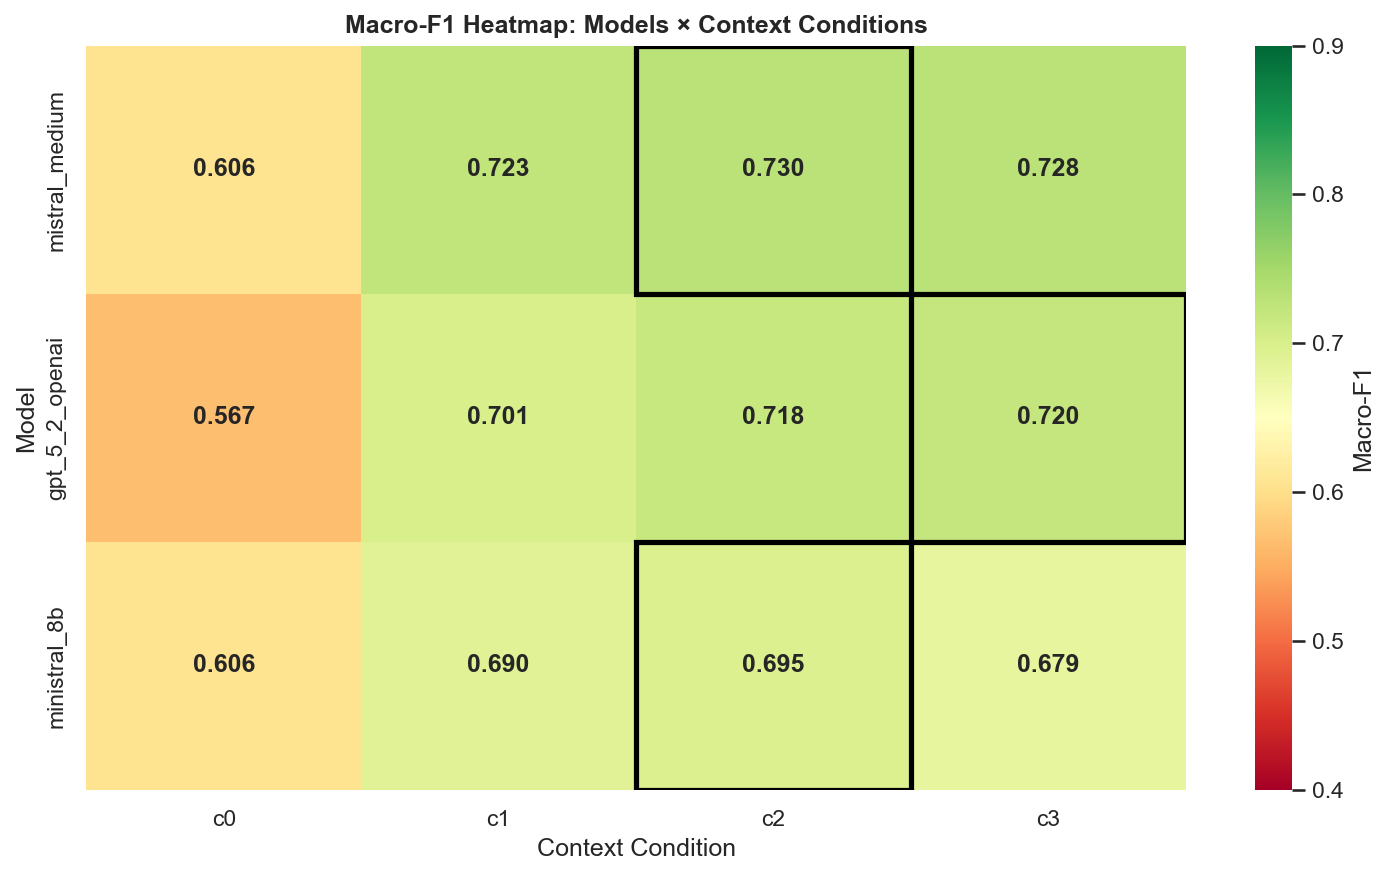

In [83]:
# F1 Heatmap with enhanced styling
from matplotlib.patches import Rectangle

if not pivot_f1.empty:
    # Sort models by mean F1 descending
    pivot_f1_sorted = pivot_f1.loc[pivot_f1.mean(axis=1).sort_values(ascending=False).index]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pivot_f1_sorted, annot=True, fmt=".3f", cmap="RdYlGn", 
                vmin=0.4, vmax=0.9, ax=ax,
                annot_kws={"size": 12, "weight": "bold"},
                cbar_kws={"label": "Macro-F1"})
    
    # Highlight max per row with rectangle
    for i, row in enumerate(pivot_f1_sorted.values):
        if not np.all(np.isnan(row)):
            j = np.nanargmax(row)
            ax.add_patch(Rectangle((j, i), 1, 1, fill=False, 
                                    edgecolor="black", linewidth=2.5))
    
    ax.set_title("Macro-F1 Heatmap: Models × Context Conditions", fontweight="bold")
    ax.set_xlabel("Context Condition")
    ax.set_ylabel("Model")
    plt.tight_layout()
    plt.show()
else:
    print("No data available for heatmap")

## Delta Analysis (Shortcut Learning)

In [84]:
# Calculate deltas: Content-Only and Shuffle vs Original
# Using df_filled for consistent 10-dataset comparison across all contexts
def calculate_deltas(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate delta_content_only and delta_shuffle for each model/context/dataset."""
    pivot = df.pivot_table(
        values="macro_f1",
        index=["model_dir", "context", "dataset"],
        columns="manipulation",
        aggfunc="mean"
    ).reset_index()
    
    if "original" in pivot.columns:
        if "content_only" in pivot.columns:
            pivot["delta_content_only"] = pivot["content_only"] - pivot["original"]
        if "shuffle" in pivot.columns:
            pivot["delta_shuffle"] = pivot["shuffle"] - pivot["original"]
    
    return pivot

deltas_df = calculate_deltas(df_filled)  # Using df_filled!
deltas_df.head()

manipulation,model_dir,context,dataset,content_only,original,shuffle,delta_content_only,delta_shuffle
0,gpt_5_2_openai,c0,ABSTRCT,0.601140,0.691936,0.601140,-0.090796,-0.090796
1,gpt_5_2_openai,c0,ACQUA,0.394334,0.618056,0.537869,-0.223721,-0.080186
2,gpt_5_2_openai,c0,AEC,0.449193,0.562290,0.444444,-0.113097,-0.117845
3,gpt_5_2_openai,c0,AFS,0.587500,0.568842,0.576380,0.018658,0.007538
4,gpt_5_2_openai,c0,ARGUMINSCI,0.333333,0.523810,0.333333,-0.190476,-0.190476


In [85]:
# Mean deltas by model and context
if "delta_content_only" in deltas_df.columns and "delta_shuffle" in deltas_df.columns:
    delta_summary = deltas_df.groupby(["model_dir", "context"])[["delta_content_only", "delta_shuffle"]].mean()
    print("Mean Deltas (negative = performance drop under manipulation)")
    display(delta_summary.round(3))
else:
    print("Not enough manipulations to calculate deltas")

Mean Deltas (negative = performance drop under manipulation)


manipulation                    delta_content_only  delta_shuffle
model_dir      context                                           
gpt_5_2_openai c0                           -0.091         -0.086
               c1                           -0.157         -0.208
               c2                           -0.130         -0.199
               c3                           -0.134         -0.156
               c3_no_guideline              -0.078         -0.125
ministral_8b   c0                           -0.133         -0.225
               c1                           -0.188         -0.285
               c2                           -0.154         -0.273
               c3                           -0.105         -0.228
               c3_no_guideline              -0.029         -0.110
mistral_medium c0                           -0.030         -0.148
               c1                           -0.167         -0.238
               c2                           -0.141         -0.209
               c3                           -0.143         -0.184
               c3_no_guideline              -0.116         -0.170

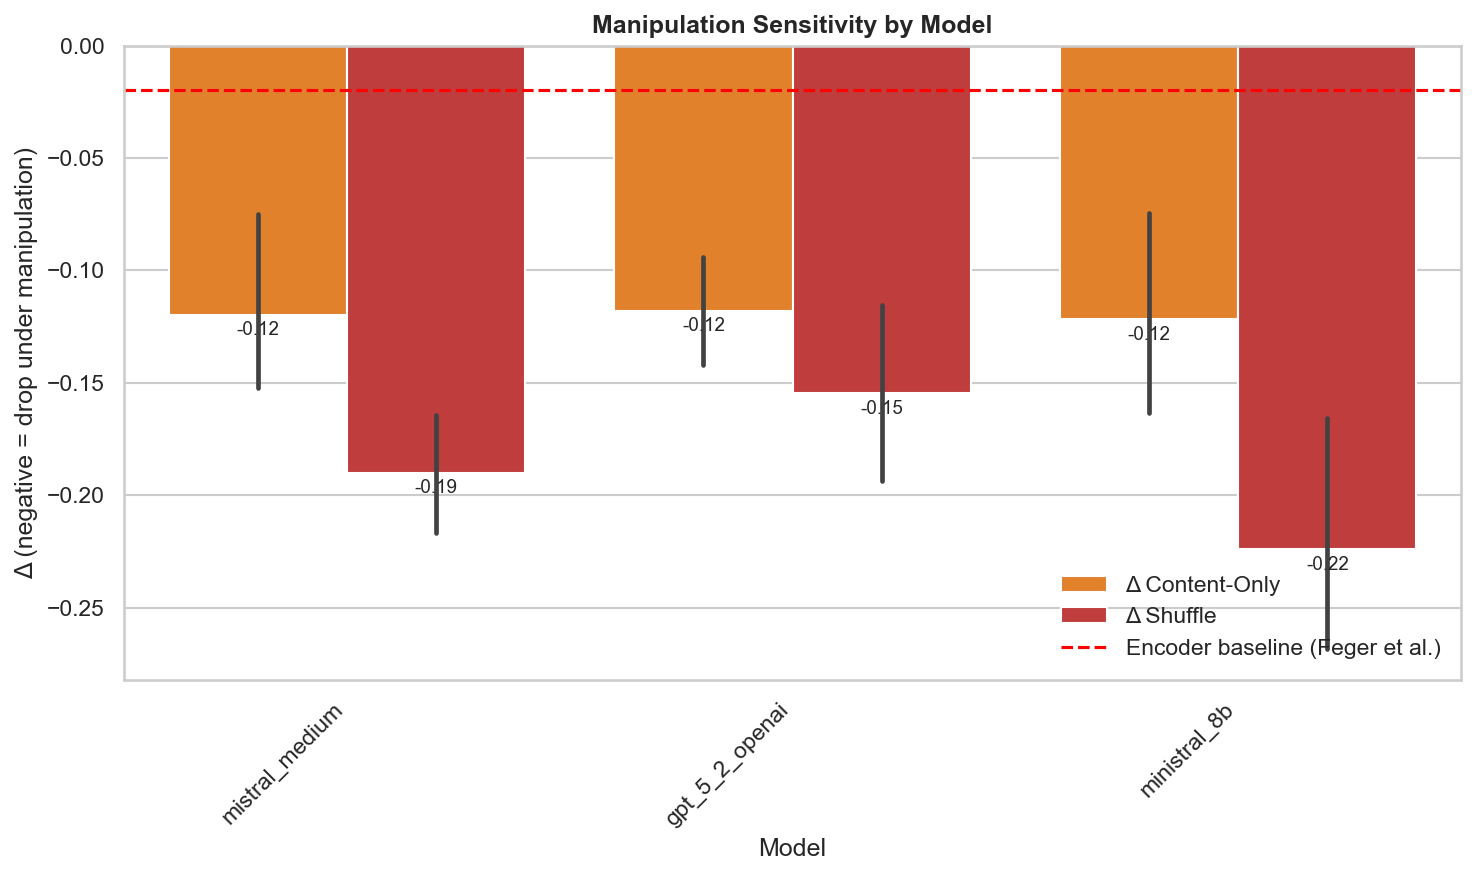

In [86]:
# =============================================================================
# DELTA BAR CHART: Manipulation Sensitivity by Model
# =============================================================================
if "delta_content_only" in deltas_df.columns and "delta_shuffle" in deltas_df.columns:
    # Prepare delta summary for plotting
    delta_plot = delta_summary.reset_index()
    delta_melted = delta_plot.melt(
        id_vars=["model_dir", "context"],
        value_vars=["delta_content_only", "delta_shuffle"],
        var_name="manipulation",
        value_name="delta"
    )
    # Rename for cleaner legend
    delta_melted["manipulation"] = delta_melted["manipulation"].map({
        "delta_content_only": "Δ Content-Only",
        "delta_shuffle": "Δ Shuffle"
    })
    
    # Sort models by mean F1 descending
    model_order = pivot_f1.mean(axis=1).sort_values(ascending=False).index.tolist()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=delta_melted, x="model_dir", y="delta", hue="manipulation", 
                ax=ax, order=model_order, palette=["#ff7f0e", "#d62728"])
    
    # Reference lines
    ax.axhline(0, color="black", linewidth=1)
    ax.axhline(-0.02, color="red", linestyle="--", linewidth=1.5, 
               label="Encoder baseline (Feger et al.)")
    
    # Value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
    
    ax.set_ylabel("Δ (negative = drop under manipulation)")
    ax.set_xlabel("Model")
    ax.set_title("Manipulation Sensitivity by Model", fontweight="bold")
    ax.legend(loc="lower right")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for delta bar chart")

## Per-Dataset Performance

In [87]:
# Per-dataset F1 for c1 (definition context)
c1_original = df[(df["context"] == "c1") & (df["manipulation"] == "original")]

if not c1_original.empty:
    per_dataset = c1_original.pivot_table(
        values="macro_f1",
        index="dataset",
        columns="model_dir",
        aggfunc="mean"
    )
    print("c1 (Definition) Macro-F1 by Dataset × Model")
    display(per_dataset.round(3))
else:
    print("No c1 results available")

c1 (Definition) Macro-F1 by Dataset × Model


model_dir,gpt_5_2_openai,ministral_8b,mistral_medium
dataset,,,
ABSTRCT,0.663,0.833,0.900
ACQUA,0.749,0.744,0.764
AEC,0.732,0.724,0.701
AFS,0.767,0.699,0.766
ARGUMINSCI,0.917,0.733,0.757
FINARG,0.438,0.542,0.583
IAM,0.764,0.681,0.782
PE,0.600,0.697,0.603
SCIARK,0.717,0.633,0.783


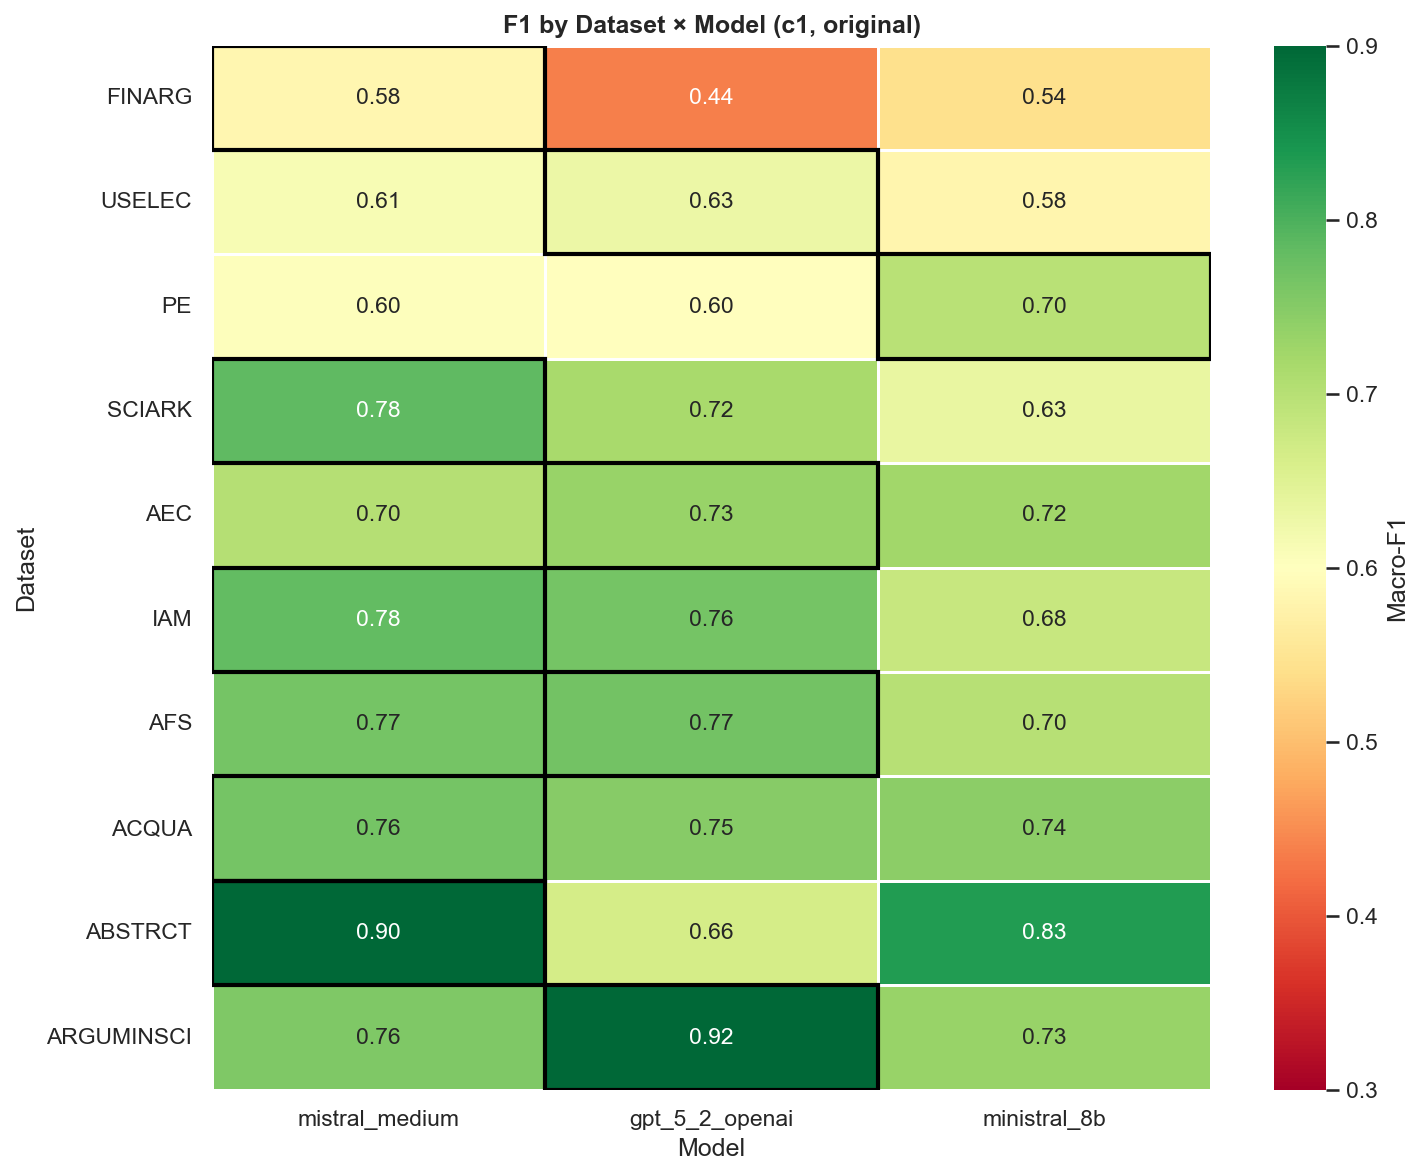

In [88]:
# =============================================================================
# PER-DATASET HEATMAP: F1 by Dataset × Model
# =============================================================================
if not c1_original.empty:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Sort datasets by mean F1, models by mean F1
    sorted_pivot = per_dataset.loc[per_dataset.mean(axis=1).sort_values().index]
    sorted_pivot = sorted_pivot[sorted_pivot.mean().sort_values(ascending=False).index]
    
    sns.heatmap(sorted_pivot, annot=True, fmt=".2f", cmap="RdYlGn",
                vmin=0.3, vmax=0.9, linewidths=0.5, ax=ax,
                annot_kws={"size": 11},
                cbar_kws={"label": "Macro-F1"})
    
    # Highlight max per row with rectangle
    for i, row in enumerate(sorted_pivot.values):
        if not np.all(np.isnan(row)):
            j = np.nanargmax(row)
            ax.add_patch(Rectangle((j, i), 1, 1, fill=False,
                                    edgecolor="black", linewidth=2))
    
    ax.set_title("F1 by Dataset × Model (c1, original)", fontweight="bold")
    ax.set_xlabel("Model")
    ax.set_ylabel("Dataset")
    plt.tight_layout()
    plt.show()
else:
    print("No c1 results available for heatmap")

## Context Ladder Visualization

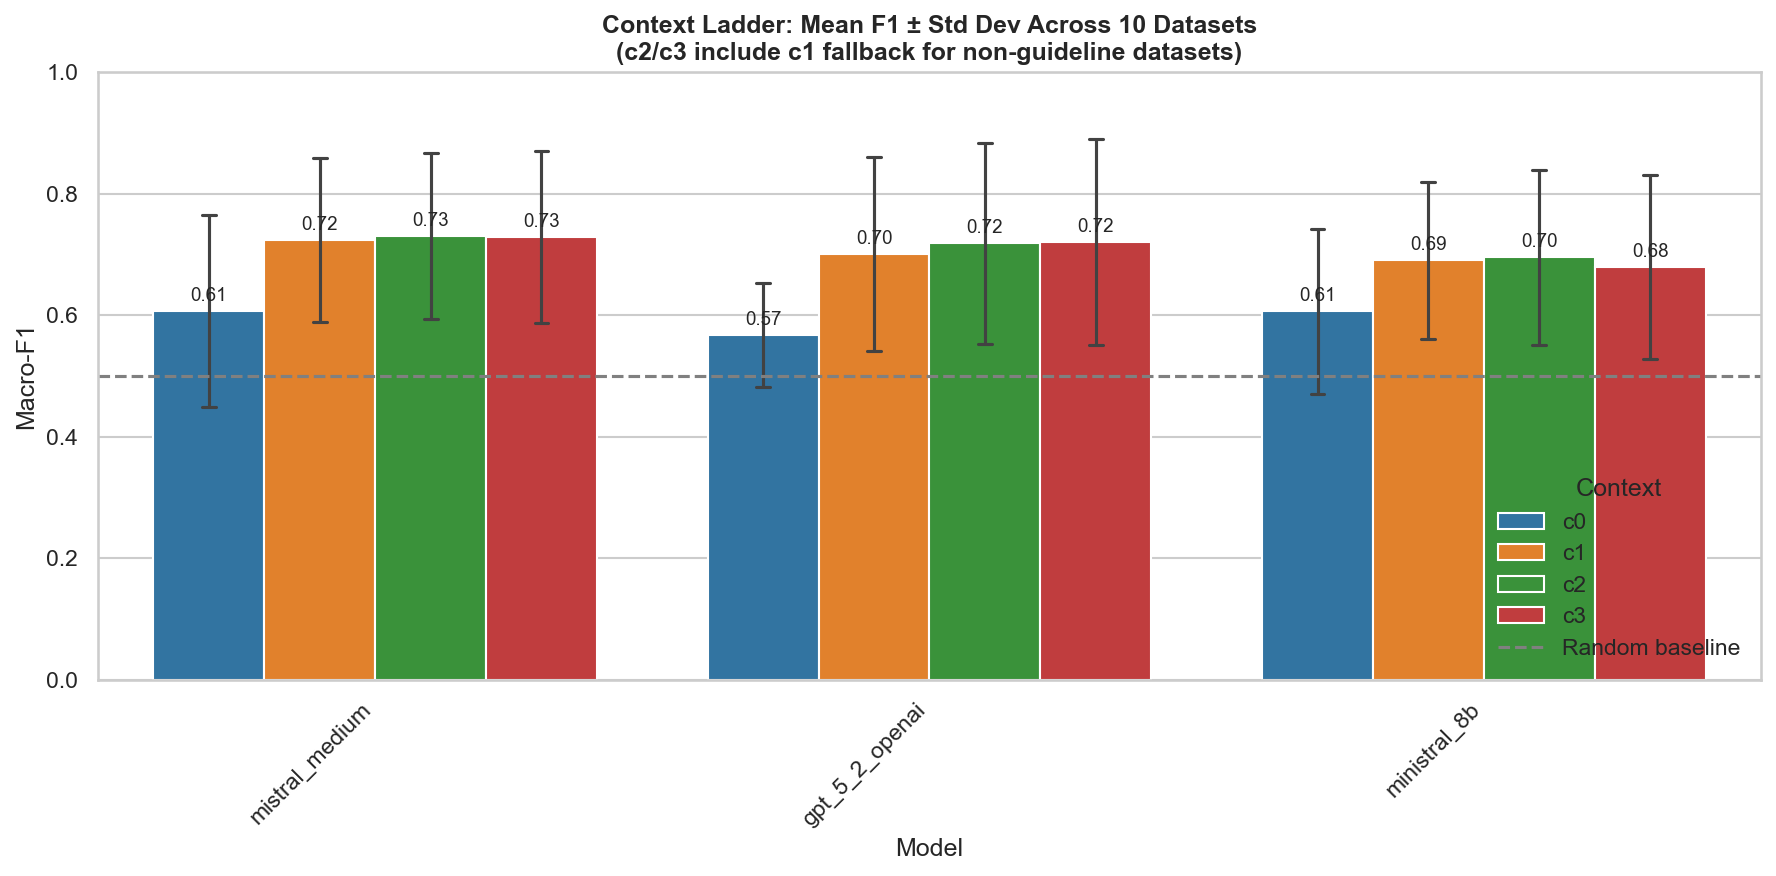

In [89]:
# Bar chart with error bars: F1 mean ± std across 10 datasets
# Using df_filled for fair 10-dataset comparison (c2/c3 include c1 fallback)
if not original_df_filled.empty:
    # Sort contexts
    context_order_list = ["c0", "c1", "c2", "c3"]
    plot_df = original_df_filled.copy()
    plot_df["context"] = pd.Categorical(
        plot_df["context"], 
        categories=[c for c in context_order_list if c in plot_df["context"].unique()],
        ordered=True
    )
    
    # Sort models by mean F1 descending
    model_order = plot_df.groupby("model_dir")["macro_f1"].mean().sort_values(ascending=False).index.tolist()
    
    # Build color palette from CONTEXT_COLORS
    available_contexts = [c for c in context_order_list if c in plot_df["context"].unique()]
    palette = [CONTEXT_COLORS.get(c, "#333333") for c in available_contexts]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=plot_df, x="model_dir", y="macro_f1", hue="context",
                order=model_order, palette=palette, ax=ax,
                errorbar="sd", capsize=0.1, err_kws={"linewidth": 1.5})
    
    # Add value labels on bars (mean values)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
    
    # Random baseline reference line
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.5, label="Random baseline")
    
    ax.set_title("Context Ladder: Mean F1 ± Std Dev Across 10 Datasets\n(c2/c3 include c1 fallback for non-guideline datasets)", fontweight="bold")
    ax.set_xlabel("Model")
    ax.set_ylabel("Macro-F1")
    ax.set_ylim(0, 1)
    ax.legend(title="Context", loc="lower right")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No data available for context ladder")

## Summary Statistics

In [90]:
# Summary: Mean F1, Std by model/context
# Using df_filled for consistent 10-dataset comparison
if not original_df_filled.empty:
    summary = original_df_filled.groupby(["model_dir", "context"])["macro_f1"].agg(["mean", "std", "count"])
    summary.columns = ["Mean F1", "Std", "N Datasets"]
    print("Summary Statistics (Original Text)")
    print("NOTE: c2/c3 include c1 fallback → all contexts show 10 datasets")
    display(summary.round(3))
else:
    print("No data available for summary")

Summary Statistics (Original Text)
NOTE: c2/c3 include c1 fallback → all contexts show 10 datasets


Mean F1    Std  N Datasets
model_dir      context                                    
gpt_5_2_openai c0                 0.567  0.086          10
               c1                 0.701  0.160          11
               c2                 0.718  0.165          11
               c3                 0.720  0.170          11
               c3_no_guideline    0.644  0.148           2
ministral_8b   c0                 0.606  0.136          10
               c1                 0.690  0.129          11
               c2                 0.695  0.144          11
               c3                 0.679  0.151          11
               c3_no_guideline    0.591  0.040           2
mistral_medium c0                 0.606  0.158          10
               c1                 0.723  0.135          11
               c2                 0.730  0.136          11
               c3                 0.728  0.142          11
               c3_no_guideline    0.687  0.107           2

In [91]:
# Export results tables
if len(df) > 0:
    # Raw results (actual experiment outputs only)
    raw_path = V1_DIR / "results_raw.csv"
    df.to_csv(raw_path, index=False)
    print(f"Exported raw results to {raw_path}")
    
    # Filled results (c2/c3 include c1 fallback for non-guideline datasets)
    filled_path = V1_DIR / "results_filled.csv"
    df_filled.to_csv(filled_path, index=False)
    print(f"Exported filled results to {filled_path}")
    print("  -> Use results_filled.csv for aggregate comparisons across context conditions")
else:
    print("No results to export yet")

Exported raw results to /Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/experiments/v3/results_raw.csv
Exported filled results to /Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/experiments/v3/results_filled.csv
  -> Use results_filled.csv for aggregate comparisons across context conditions


## Comprehensive Performance Tables

In [92]:
# =============================================================================
# TABLE 1: F1 Scores by Model x Context x Dataset
# =============================================================================

all_datasets = sorted(df["dataset"].unique())
original_only = df[df["manipulation"] == "original"]

# Pivot: rows = (model_dir, context), columns = dataset
f1_pivot = original_only.pivot_table(
    values="macro_f1",
    index=["model_dir", "context"],
    columns="dataset",
    aggfunc="mean"
)
f1_pivot["Avg"] = f1_pivot.mean(axis=1)

# Sort by context order
context_order = {"c0": 0, "c1": 1, "c2": 2, "c3": 3}
f1_pivot = f1_pivot.sort_index(
    key=lambda x: x.map(lambda v: context_order.get(v, 99)) if x.name == "context" else x
)

print("=== F1 Scores (Original Text) ===\n")
print(f1_pivot.round(3).to_string())

# Enhanced styling: gradient first, then max highlight with border only (no background override)
styled_f1 = f1_pivot.style.background_gradient(
    cmap="RdYlGn", vmin=0.3, vmax=0.8
).highlight_max(
    axis=1, props="font-weight:bold; border:2px solid black"
).format("{:.3f}", na_rep="-")
display(styled_f1)

=== F1 Scores (Original Text) ===

dataset                         ABSTRCT  ACQUA    AEC    AFS  ARGUMINSCI  FINARG    IAM     PE  SCIARK  USELEC    Avg
model_dir      context                                                                                               
gpt_5_2_openai c0                 0.692  0.618  0.562  0.569       0.524   0.405  0.563  0.666   0.601   0.472  0.567
               c1                 0.663  0.749  0.732  0.767       0.917   0.438  0.764  0.600   0.717   0.630  0.698
               c2                 0.883    NaN    NaN    NaN       0.883     NaN    NaN  0.583     NaN   0.649  0.750
               c3                 0.917    NaN    NaN    NaN       0.847     NaN    NaN  0.524     NaN   0.738  0.756
               c3_no_guideline      NaN    NaN    NaN    NaN         NaN   0.540    NaN    NaN   0.748     NaN  0.644
ministral_8b   c0                 0.738  0.748  0.451  0.514       0.496   0.426  0.764  0.676   0.729   0.520  0.606
               c1    

In [93]:
# =============================================================================
# TABLE 2: Manipulation Sensitivity (Delta values)
# =============================================================================
# More negative delta = larger performance drop = relies on linguistic structure

delta_cols = ["delta_content_only", "delta_shuffle"]
if all(c in deltas_df.columns for c in delta_cols):
    # Aggregate deltas by model/context
    delta_agg = deltas_df.groupby(["model_dir", "context"]).agg({
        "delta_content_only": "mean",
        "delta_shuffle": "mean",
        "dataset": "count"
    }).rename(columns={"dataset": "n_datasets"})
    
    # Add mean absolute delta
    delta_agg["mean_abs_delta"] = (
        delta_agg["delta_content_only"].abs() + delta_agg["delta_shuffle"].abs()
    ) / 2
    
    # Sort by context order
    delta_agg = delta_agg.sort_index(
        key=lambda x: x.map(lambda v: context_order.get(v, 99)) if x.name == "context" else x
    )
    
    print("=== Manipulation Sensitivity (Delta values) ===")
    print("More negative = higher sensitivity to manipulation\n")
    print(delta_agg.round(3).to_string())
    
    # Enhanced styling: gradient + max highlight with border only
    styled_delta = delta_agg.style.background_gradient(
        subset=["delta_content_only", "delta_shuffle"],
        cmap="RdYlGn_r",  # Reversed: negative (green) to positive (red)
        vmin=-0.4, vmax=0.1
    ).background_gradient(
        subset=["mean_abs_delta"],
        cmap="RdYlGn",
        vmin=0.0, vmax=0.3
    ).highlight_max(
        subset=["delta_content_only", "delta_shuffle"],
        axis=0, props="font-weight:bold; border:2px solid black"
    ).format("{:.3f}")
    display(styled_delta)
else:
    print("Insufficient manipulation data for delta analysis")

=== Manipulation Sensitivity (Delta values) ===
More negative = higher sensitivity to manipulation

manipulation                    delta_content_only  delta_shuffle  n_datasets  mean_abs_delta
model_dir      context                                                                       
gpt_5_2_openai c0                           -0.091         -0.086          10           0.089
               c1                           -0.157         -0.208          10           0.182
               c2                           -0.130         -0.199          10           0.164
               c3                           -0.134         -0.156          10           0.145
               c3_no_guideline              -0.078         -0.125           2           0.102
ministral_8b   c0                           -0.133         -0.225          10           0.179
               c1                           -0.188         -0.285          10           0.236
               c2                           -0.154    

In [94]:
# =============================================================================
# TABLE 3: F1 by Manipulation (original, content_only, shuffle) per Dataset
# =============================================================================

manip_pivot = df.pivot_table(
    values="macro_f1",
    index=["model_dir", "context", "dataset"],
    columns="manipulation",
    aggfunc="mean"
)

# Reorder columns
col_order = [c for c in ["original", "content_only", "shuffle"] if c in manip_pivot.columns]
manip_pivot = manip_pivot[col_order]
manip_pivot["Avg"] = manip_pivot.mean(axis=1)

# Sort by context order
manip_pivot = manip_pivot.sort_index(
    key=lambda x: x.map(lambda v: context_order.get(v, 99)) if x.name == "context" else x
)

print("=== F1 by Manipulation per Dataset ===\n")
print(manip_pivot.round(3).to_string())

# Enhanced styling: gradient + max highlight with border only
styled_manip = manip_pivot.style.background_gradient(
    cmap="RdYlGn", vmin=0.3, vmax=0.8
).highlight_max(
    axis=1, props="font-weight:bold; border:2px solid black"
).format("{:.3f}", na_rep="-")
display(styled_manip)

=== F1 by Manipulation per Dataset ===

manipulation                               original  content_only  shuffle    Avg
model_dir      context         dataset                                           
gpt_5_2_openai c0              ABSTRCT        0.692         0.601    0.601  0.631
                               ACQUA          0.618         0.394    0.538  0.517
                               AEC            0.562         0.449    0.444  0.485
                               AFS            0.569         0.588    0.576  0.578
                               ARGUMINSCI     0.524         0.333    0.333  0.397
                               FINARG         0.405         0.326    0.369  0.367
                               IAM            0.563         0.653    0.569  0.595
                               PE             0.666         0.524    0.533  0.575
                               SCIARK         0.601         0.538    0.524  0.554
                               USELEC         0.472       

## RQ1: Does Additional Context Improve Classification?

This analysis focuses on the 4 datasets where annotation guidelines are available: **ABSTRCT, ARGUMINSCI, PE, USELEC**. These allow testing the full context ladder:

| Level | Context Provided |
|-------|------------------|
| c0 | None (zero-shot baseline) |
| c1 | Definition of "argument" from source paper |
| c2 | c1 + Annotation guideline (what annotators were told) |
| c3 | c2 + Document context (preceding sentences) |

**Why this matters for the thesis:** If LLMs can leverage annotation guidelines to match human annotator behavior, this suggests they can generalize across datasets by adapting to different argument definitions rather than learning dataset-specific shortcuts.

In [95]:
# =============================================================================
# GUIDELINE DATASETS: Context Ladder c0 → c3
# =============================================================================

# Filter to guideline datasets and original manipulation
guideline_df = df[
    (df["dataset"].isin(GUIDELINE_DATASETS)) & 
    (df["manipulation"] == "original")
].copy()

# Ensure context order
context_order_full = ["c0", "c1", "c2", "c3"]
guideline_df["context"] = pd.Categorical(
    guideline_df["context"],
    categories=[c for c in context_order_full if c in guideline_df["context"].unique()],
    ordered=True
)

# Pivot for grouped bar chart: datasets as groups, contexts as bars
guideline_pivot = guideline_df.pivot_table(
    values="macro_f1",
    index=["model_dir", "dataset"],
    columns="context",
    aggfunc="mean"
).reset_index()

print(f"Guideline datasets available contexts: {sorted(guideline_df['context'].dropna().unique())}")
print(f"Models: {sorted(guideline_df['model_dir'].unique())}")
guideline_pivot

Guideline datasets available contexts: ['c0', 'c1', 'c2', 'c3']
Models: ['gpt_5_2_openai', 'ministral_8b', 'mistral_medium']


/var/folders/4g/91bm8hl51ld9v8c8tg6_lrqw0000gn/T/ipykernel_53905/2731830732.py:20: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  guideline_pivot = guideline_df.pivot_table(


context,model_dir,dataset,c0,c1,c2,c3
0,gpt_5_2_openai,ABSTRCT,0.691936,0.663300,0.883301,0.916644
1,gpt_5_2_openai,ARGUMINSCI,0.523810,0.916644,0.883041,0.846547
2,gpt_5_2_openai,PE,0.666296,0.599555,0.583333,0.523810
3,gpt_5_2_openai,USELEC,0.472485,0.629630,0.649123,0.737686
4,ministral_8b,ABSTRCT,0.737686,0.833148,0.949986,0.899889
5,ministral_8b,ARGUMINSCI,0.495798,0.733037,0.667735,0.733037
6,ministral_8b,PE,0.676044,0.696970,0.603334,0.474479
7,ministral_8b,USELEC,0.520000,0.580420,0.678964,0.619450
8,mistral_medium,ABSTRCT,0.764310,0.900000,0.916644,0.933259
9,mistral_medium,ARGUMINSCI,0.576380,0.756944,0.753231,0.753231


/var/folders/4g/91bm8hl51ld9v8c8tg6_lrqw0000gn/T/ipykernel_53905/1055181210.py:23: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = model_data.pivot_table(
/var/folders/4g/91bm8hl51ld9v8c8tg6_lrqw0000gn/T/ipykernel_53905/1055181210.py:23: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = model_data.pivot_table(
/var/folders/4g/91bm8hl51ld9v8c8tg6_lrqw0000gn/T/ipykernel_53905/1055181210.py:23: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = model_data.pivot_table(


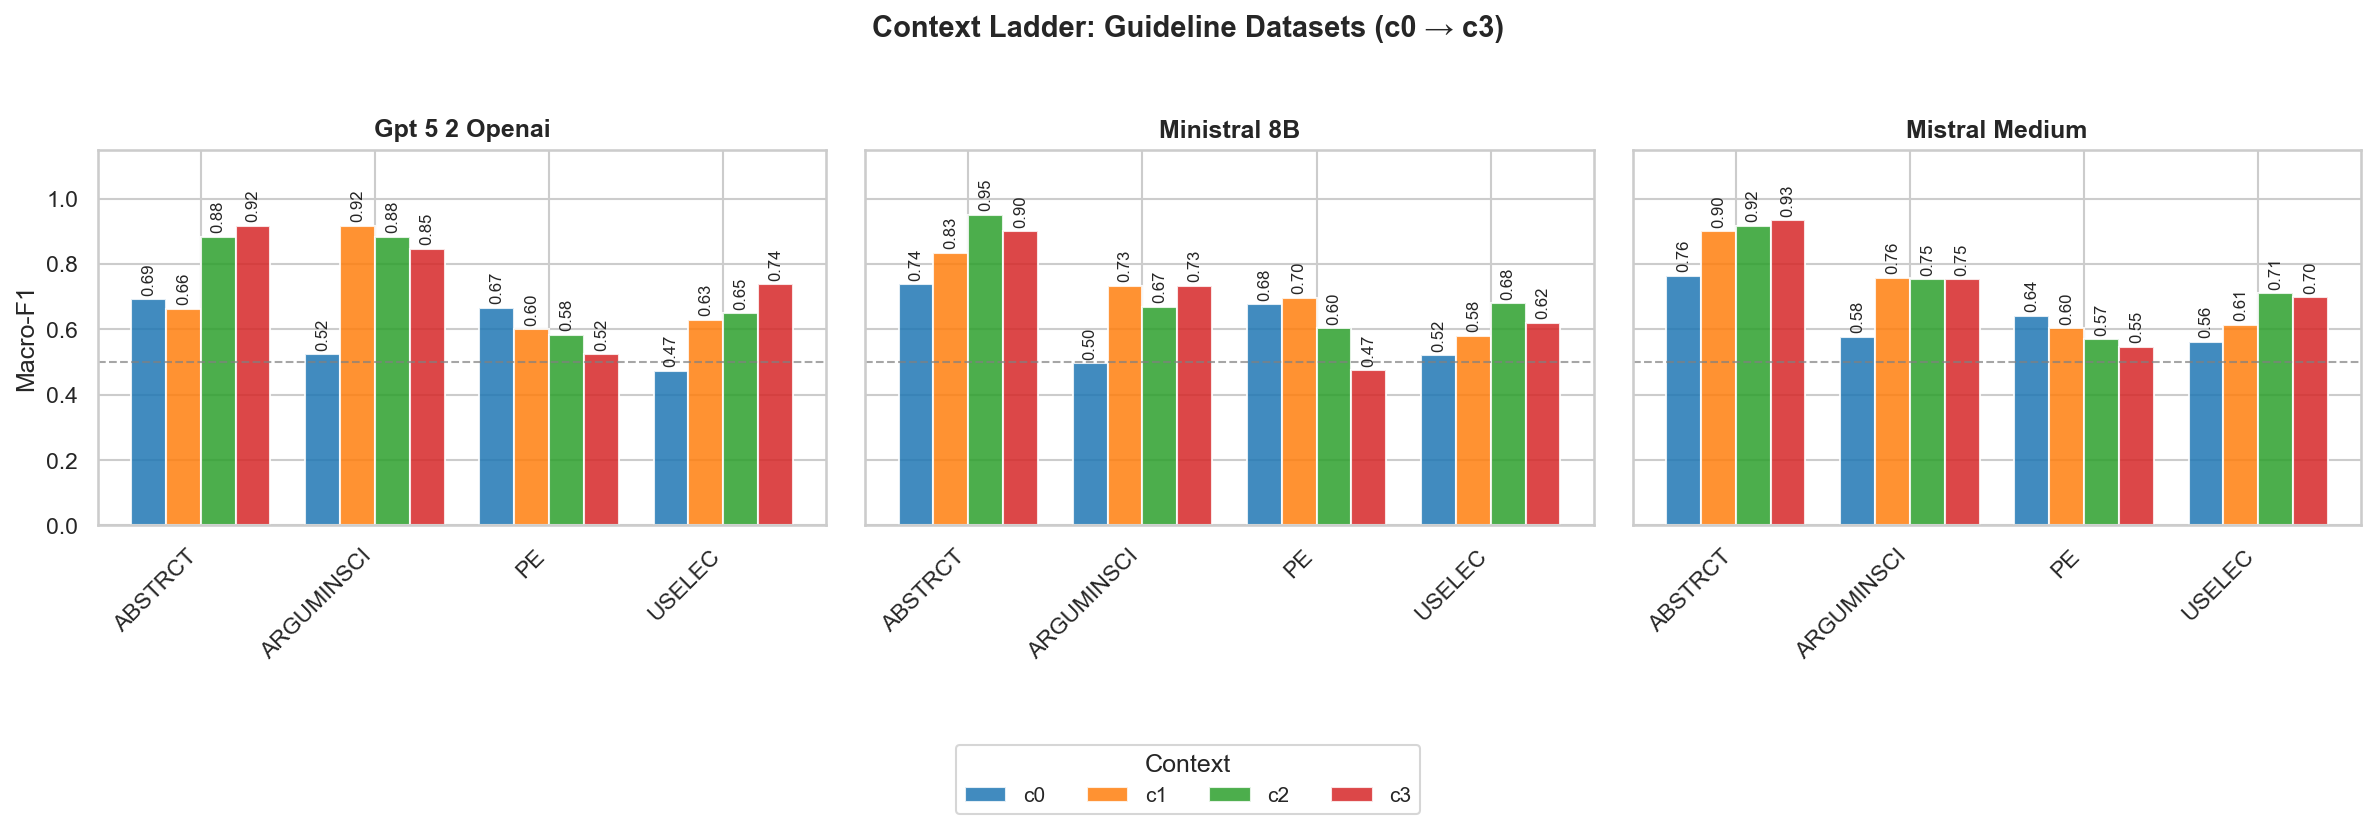

In [96]:
# =============================================================================
# PLOT 1: Grouped Bar Chart - Context Ladder per Dataset (Faceted by Model)
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

models = sorted(guideline_df["model_dir"].unique())
datasets_ordered = ["ABSTRCT", "ARGUMINSCI", "PE", "USELEC"]
available_contexts = [c for c in context_order_full if c in guideline_df["context"].unique()]

# Extended color palette for c0-c3
CONTEXT_COLORS_FULL = {
    "c0": "#1f77b4",  # blue
    "c1": "#ff7f0e",  # orange  
    "c2": "#2ca02c",  # green
    "c3": "#d62728",  # red
}

for ax, model in zip(axes, models):
    model_data = guideline_df[guideline_df["model_dir"] == model]
    
    # Pivot for this model
    pivot = model_data.pivot_table(
        values="macro_f1",
        index="dataset",
        columns="context",
        aggfunc="mean"
    ).reindex(datasets_ordered)
    
    # Bar positions
    x = np.arange(len(datasets_ordered))
    width = 0.2
    n_contexts = len(available_contexts)
    
    for i, ctx in enumerate(available_contexts):
        if ctx in pivot.columns:
            offset = (i - (n_contexts - 1) / 2) * width
            bars = ax.bar(x + offset, pivot[ctx], width, 
                         label=ctx, color=CONTEXT_COLORS_FULL[ctx], alpha=0.85)
            # Value labels
            ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8, rotation=90)
    
    ax.set_xticks(x)
    ax.set_xticklabels(datasets_ordered, rotation=45, ha="right")
    ax.set_title(model.replace("_", " ").title(), fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.7)

axes[0].set_ylabel("Macro-F1")

# Legend outside plot area (below the figure)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Context", loc="upper center", 
           bbox_to_anchor=(0.5, 0.02), ncol=4, frameon=True, fontsize=10)

fig.suptitle("Context Ladder: Guideline Datasets (c0 → c3)", fontweight="bold", fontsize=14)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig(V1_DIR / "plot_guideline_context_ladder.png", dpi=150, bbox_inches="tight")
plt.show()

### Observations

**Definition helps consistently (c0 → c1):** All models show improvement when given a definition. The effect is strongest on ARGUMINSCI (+0.18 to +0.39 F1), where the zero-shot baseline is near random.

**Guidelines help selectively (c1 → c2):** ABSTRCT and USELEC benefit from guidelines across models. ARGUMINSCI shows mixed results — GPT-5.2 drops slightly while Mistral stays flat. This suggests guidelines are most useful when the definition alone is ambiguous.

**Document context is unreliable (c2 → c3):** Adding preceding sentences hurts PE consistently (all models drop). USELEC is the only dataset where c3 outperforms c2. This matches the hypothesis that document context can introduce noise when sentences are self-contained.

### Why PE Shows Inverted Context Effects (c0 > c1 > c2 > c3)

PE annotations follow **categorical exclusion rules** that conflict with relational reasoning:
- Recommendations → Non-argumentative (regardless of supporting reasons)
- Shell language ("I believe") → Excluded
- Reporting others' views → Non-argumentative

**Why context hurts:** The definition frames arguments as "components connected by support relations." When the model sees document context with apparent support structures, it infers argumentativeness — but PE annotators applied categorical rules that ignore such relations.

**Example:** "Parent should find friends..." is labeled No-Argument (recommendation), even though preceding sentences provide supporting reasons. More context = more "evidence" of relations = wrong predictions.

**Implication:** Context degrades performance when annotation rules are categorical rather than relational.

In [97]:
# =============================================================================
# Context Impact Deltas: How much does each context level add?
# =============================================================================

# Calculate deltas: c1-c0, c2-c1, c3-c2
context_deltas = []
for model in guideline_df["model_dir"].unique():
    for dataset in GUIDELINE_DATASETS:
        model_ds = guideline_df[(guideline_df["model_dir"] == model) & 
                                 (guideline_df["dataset"] == dataset)]
        
        f1_by_ctx = model_ds.set_index("context")["macro_f1"].to_dict()
        
        row = {"model": model, "dataset": dataset}
        row["c0"] = f1_by_ctx.get("c0", np.nan)
        row["c1"] = f1_by_ctx.get("c1", np.nan)
        row["c2"] = f1_by_ctx.get("c2", np.nan)
        row["c3"] = f1_by_ctx.get("c3", np.nan)
        
        # Deltas
        if "c0" in f1_by_ctx and "c1" in f1_by_ctx:
            row["Δ(c1-c0)"] = f1_by_ctx["c1"] - f1_by_ctx["c0"]
        if "c1" in f1_by_ctx and "c2" in f1_by_ctx:
            row["Δ(c2-c1)"] = f1_by_ctx["c2"] - f1_by_ctx["c1"]
        if "c2" in f1_by_ctx and "c3" in f1_by_ctx:
            row["Δ(c3-c2)"] = f1_by_ctx["c3"] - f1_by_ctx["c2"]
        
        context_deltas.append(row)

context_delta_df = pd.DataFrame(context_deltas)

print("=== Context Impact Deltas (Guideline Datasets) ===")
print("Positive = improvement, Negative = degradation\n")

# Style the delta columns
delta_cols = [c for c in context_delta_df.columns if c.startswith("Δ")]
styled = context_delta_df.style.background_gradient(
    subset=delta_cols,
    cmap="RdYlGn",
    vmin=-0.2, vmax=0.2
).format("{:.3f}", subset=["c0", "c1", "c2", "c3"] + delta_cols, na_rep="-")
display(styled)

=== Context Impact Deltas (Guideline Datasets) ===
Positive = improvement, Negative = degradation



,model,dataset,c0,c1,c2,c3,Δ(c1-c0),Δ(c2-c1),Δ(c3-c2)
0,ministral_8b,PE,0.676,0.697,0.603,0.474,0.021,-0.094,-0.129
1,ministral_8b,ARGUMINSCI,0.496,0.733,0.668,0.733,0.237,-0.065,0.065
2,ministral_8b,USELEC,0.520,0.580,0.679,0.619,0.060,0.099,-0.060
3,ministral_8b,ABSTRCT,0.738,0.833,0.950,0.900,0.095,0.117,-0.050
4,gpt_5_2_openai,PE,0.666,0.600,0.583,0.524,-0.067,-0.016,-0.060
5,gpt_5_2_openai,ARGUMINSCI,0.524,0.917,0.883,0.847,0.393,-0.034,-0.036
6,gpt_5_2_openai,USELEC,0.472,0.630,0.649,0.738,0.157,0.019,0.089
7,gpt_5_2_openai,ABSTRCT,0.692,0.663,0.883,0.917,-0.029,0.220,0.033
8,mistral_medium,PE,0.641,0.603,0.569,0.547,-0.038,-0.034,-0.022
9,mistral_medium,ARGUMINSCI,0.576,0.757,0.753,0.753,0.181,-0.004,0.000


### Context Impact Summary

The table above shows absolute F1 at each context level and the delta between consecutive levels. Green = improvement, red = degradation.

**Key findings:**
- Δ(c1-c0) is positive for 10/12 model×dataset combinations — definitions help almost universally
- Δ(c2-c1) is positive for only 6/12 — guidelines are dataset-dependent  
- Δ(c3-c2) is negative for 7/12 — document context often hurts

**Implication:** The optimal context level is not "more is better." For some datasets (PE), zero-shot outperforms the full context stack. The thesis should investigate what makes certain datasets respond negatively to additional context.

## RQ2: Which Datasets Remain Challenging?

This plot shows the performance spread for each dataset across all model × context combinations. The gray bar spans from the worst to best configuration; markers show lowest (red), average (orange), and best (green) F1.

**Why this matters for the thesis:** Datasets with high variance suggest performance depends heavily on choosing the right model/context — the task itself is tractable. Datasets where even the best configuration is near 0.5 indicate a fundamental difficulty that no current approach solves.

In [98]:
# =============================================================================
# PLOT 2: Best / Average / Lowest Performance per Dataset
# =============================================================================

# Get original text only
original_only = df[df["manipulation"] == "original"]

# Aggregate by dataset: min, mean, max across all model×context combinations
dataset_perf = original_only.groupby("dataset")["macro_f1"].agg(["min", "mean", "max"])
dataset_perf.columns = ["Lowest", "Average", "Best"]

# Find best configuration for each dataset
best_configs = []
for dataset in dataset_perf.index:
    ds_data = original_only[original_only["dataset"] == dataset]
    best_idx = ds_data["macro_f1"].idxmax()
    best_row = ds_data.loc[best_idx]
    best_configs.append({
        "dataset": dataset,
        "best_config": f"{best_row['model_dir']} ({best_row['context']})",
        "best_f1": best_row["macro_f1"]
    })
best_config_df = pd.DataFrame(best_configs).set_index("dataset")

# Merge
dataset_perf = dataset_perf.join(best_config_df)

# Sort by best F1
dataset_perf = dataset_perf.sort_values("Best", ascending=True)

print("=== Performance Range per Dataset ===\n")
display(dataset_perf.round(3))

=== Performance Range per Dataset ===



,Lowest,Average,Best,best_config,best_f1
dataset,,,,,
FINARG,0.365,0.497,0.611,mistral_medium (c3_no_guideline),0.611
PE,0.474,0.599,0.697,ministral_8b (c1),0.697
USELEC,0.472,0.623,0.738,gpt_5_2_openai (c3),0.738
ACQUA,0.618,0.726,0.764,mistral_medium (c1),0.764
AFS,0.451,0.627,0.767,gpt_5_2_openai (c1),0.767
IAM,0.563,0.702,0.782,mistral_medium (c1),0.782
SCIARK,0.601,0.718,0.867,mistral_medium (c0),0.867
ARGUMINSCI,0.496,0.720,0.917,gpt_5_2_openai (c1),0.917
ABSTRCT,0.663,0.841,0.950,ministral_8b (c2),0.950


In [99]:
# =============================================================================
# Horizontal Bar Chart: Performance Range per Dataset (Professional Design)
# =============================================================================

# Professional color palette
plt.close('all')  # Clear any previous figures
COLORS = {
    "range": "#E8E8E8",      # Light gray for range bar
    "lowest": "#C44E52",     # Muted red
    "average": "#4C72B0",    # Steel blue  
    "best": "#55A868",       # Muted green
    "baseline": "#8C8C8C",   # Gray
    "text": "#333333",       # Dark gray for text
}

fig, ax = plt.subplots(figsize=(10, 7))

# Set white background with subtle styling
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

datasets = dataset_perf.index.tolist()
y_pos = np.arange(len(datasets))

# Draw range bars and markers
for i, ds in enumerate(datasets):
    row = dataset_perf.loc[ds]
    
    # Range bar (elegant rounded appearance via zorder)
    ax.barh(i, row["Best"] - row["Lowest"], left=row["Lowest"], 
            height=0.35, color=COLORS["range"], edgecolor="none", zorder=1)
    
    # Connecting line through the range
    ax.plot([row["Lowest"], row["Best"]], [i, i], 
            color="#B0B0B0", linewidth=1.5, zorder=2)
    
    # Markers with professional styling
    ax.scatter(row["Lowest"], i, color=COLORS["lowest"], s=80, zorder=4, 
               marker="D", edgecolors="white", linewidths=0.8,
               label="Worst" if i == 0 else "")
    
    ax.scatter(row["Average"], i, color=COLORS["average"], s=100, zorder=4, 
               marker="o", edgecolors="white", linewidths=0.8,
               label="Mean" if i == 0 else "")
    
    ax.scatter(row["Best"], i, color=COLORS["best"], s=80, zorder=4, 
               marker="D", edgecolors="white", linewidths=0.8,
               label="Best" if i == 0 else "")
    
    # Best config annotation - clean positioning
    config_text = row["best_config"].replace("_", " ")
    ax.annotate(config_text, 
                xy=(row["Best"] + 0.015, i), 
                va="center", ha="left",
                fontsize=8, color=COLORS["text"], fontstyle="italic",
                alpha=0.85)

# Axis styling
ax.set_yticks(y_pos)
ax.set_yticklabels(datasets, fontsize=11, fontweight="medium")
ax.set_xlabel("Macro-F1", fontsize=12, labelpad=10)
ax.set_xlim(0.3, 1.05)

# Random baseline
ax.axvline(0.5, color=COLORS["baseline"], linestyle="--", linewidth=1.2, 
           alpha=0.6, label="Random", zorder=0)

# Grid - subtle horizontal only
ax.xaxis.grid(True, linestyle="-", alpha=0.15, color="#000000")
ax.yaxis.grid(False)

# Spine styling
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["bottom", "left"]:
    ax.spines[spine].set_color("#CCCCCC")
    ax.spines[spine].set_linewidth(0.8)

# Legend - clean horizontal layout
legend = ax.legend(loc="lower right", frameon=True, framealpha=0.95,
                   edgecolor="#CCCCCC", fontsize=9, ncol=4,
                   handletextpad=0.4, columnspacing=1.2)
legend.get_frame().set_linewidth(0.5)

# Title
ax.set_title("Performance Range by Dataset", 
             fontsize=14, fontweight="bold", pad=15, color=COLORS["text"])

plt.tight_layout()
plt.savefig(V1_DIR / "plot_dataset_performance_range.png", dpi=200, bbox_inches="tight", 
            facecolor="white", edgecolor="none")
plt.savefig(V1_DIR / "plot_dataset_performance_range.pdf", bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.close(fig)


### Observations

**High-performing datasets (F1 > 0.85):**
- ABSTRCT (0.95) and ARGUMINSCI (0.92) reach near-human performance with the right configuration
- Both benefit from guidelines (c2) — this supports the GAIC task hypothesis that context enables generalization

**Challenging datasets (F1 < 0.6):**
- AEC (0.56) and FINARG (0.58) barely exceed random baseline even with the best model/context
- These may require domain-specific knowledge (architecture, finance) not captured by general LLMs

**High variance datasets:**
- ARGUMINSCI has the largest range (0.42) — zero-shot fails but with definition it works
- This is evidence that context compensates for lack of dataset-specific training

**Best configurations are not uniform:**
- No single model dominates — mistral_medium wins on 4 datasets, GPT-5.2 on 3, ministral_8b on 3
- Context level varies: c0 wins for SCIARK (contamination?), c3 wins for USELEC
- This suggests model selection should be dataset-aware in practice

In [100]:
# =============================================================================
# Summary: Best Configuration per Dataset
# =============================================================================

# Create clean summary table
summary_table = dataset_perf[["best_config", "Best", "Lowest", "Average"]].copy()
summary_table["Range"] = summary_table["Best"] - summary_table["Lowest"]
summary_table = summary_table.sort_values("Best", ascending=False)
summary_table.columns = ["Best Config", "Best F1", "Lowest F1", "Avg F1", "Range"]

print("=== Best Configuration per Dataset ===")
print("Sorted by Best F1 descending\n")

styled = summary_table.style.background_gradient(
    subset=["Best F1", "Lowest F1", "Avg F1"],
    cmap="RdYlGn", vmin=0.3, vmax=0.95
).background_gradient(
    subset=["Range"],
    cmap="Blues", vmin=0, vmax=0.4
).format("{:.3f}", subset=["Best F1", "Lowest F1", "Avg F1", "Range"])
display(styled)

=== Best Configuration per Dataset ===
Sorted by Best F1 descending



,Best Config,Best F1,Lowest F1,Avg F1,Range
dataset,,,,,
AEC,gpt_5_2_openai (c1),0.967,0.444,0.641,0.522
ABSTRCT,ministral_8b (c2),0.950,0.663,0.841,0.287
ARGUMINSCI,gpt_5_2_openai (c1),0.917,0.496,0.720,0.421
SCIARK,mistral_medium (c0),0.867,0.601,0.718,0.266
IAM,mistral_medium (c1),0.782,0.563,0.702,0.219
AFS,gpt_5_2_openai (c1),0.767,0.451,0.627,0.316
ACQUA,mistral_medium (c1),0.764,0.618,0.726,0.146
USELEC,gpt_5_2_openai (c3),0.738,0.472,0.623,0.265
PE,ministral_8b (c1),0.697,0.474,0.599,0.222


## Comparison with Encoder Baselines (Feger et al., ACL 2025)

Comparing zero-shot LLM performance against supervised encoder models from the benchmark study. SOTA values are the best in-domain (diagonal) results from fine-tuned WRAP, BERT, RoBERTa, and DistilBERT.

In [101]:
# =============================================================================
# Feger et al. (ACL 2025) Encoder Baselines
# =============================================================================

# SOTA: Best in-domain (diagonal) performance from Figure 1
# Format: (F1, best_model) where model is W=WRAP, B=BERT, R=RoBERTa, D=DistilBERT
FEGER_SOTA = {
    "ABSTRCT":    (0.89, "BERT"),
    "ACQUA":      (0.84, "RoBERTa"),
    "AEC":        (0.96, "BERT"),
    "AFS":        (0.84, "DistilBERT"),
    "ARGUMINSCI": (0.84, "DistilBERT"),
    "FINARG":     (0.69, "DistilBERT"),
    "IAM":        (0.76, "WRAP"),
    "PE":         (0.78, "BERT"),
    "SCIARK":     (0.83, "BERT"),
    "USELEC":     (0.66, "BERT"),
}

# Post-manipulation SOTA from Table 5 (worst performance after content-only/shuffle)
FEGER_POST_MANIP = {
    "ABSTRCT":    0.89,
    "ACQUA":      0.84,
    "AEC":        0.96,
    "AFS":        0.84,
    "ARGUMINSCI": 0.84,
    "FINARG":     0.68,
    "IAM":        0.76,
    "PE":         0.78,
    "SCIARK":     0.83,
    "USELEC":     0.74,
}

# =============================================================================
# k-NN Baseline (k=50, per-dataset retrieval - best variant)
# =============================================================================
# Embedding-based retrieval: classify by majority vote of k nearest training samples
# Uses text-embedding-3-small embeddings in ChromaDB
KNN_BASELINE = {
    "ABSTRCT":    0.8667,
    "ACQUA":      0.6606,
    "AEC":        0.5978,
    "AFS":        0.7600,
    "ARGUMINSCI": 0.6914,
    "FINARG":     0.6110,
    "IAM":        0.5978,
    "PE":         0.5739,
    "SCIARK":     0.7129,
    "USELEC":     0.6946,
}

In [102]:
# =============================================================================
# PLOT: LLM Best vs Encoder SOTA vs k-NN Baseline (Original Text)
# =============================================================================

# Get our best F1 per dataset (original text only)
original_only = df[df["manipulation"] == "original"]
our_best = original_only.groupby("dataset").agg({
    "macro_f1": "max"
}).rename(columns={"macro_f1": "LLM Best"})

# Find best config for each dataset
for dataset in our_best.index:
    ds_data = original_only[original_only["dataset"] == dataset]
    best_idx = ds_data["macro_f1"].idxmax()
    best_row = ds_data.loc[best_idx]
    our_best.loc[dataset, "LLM Config"] = f"{best_row['model_dir'].replace('_', ' ').title()} ({best_row['context']})"

# Add Feger SOTA
our_best["Encoder SOTA"] = our_best.index.map(lambda x: FEGER_SOTA.get(x, (np.nan, ""))[0])
our_best["Encoder Model"] = our_best.index.map(lambda x: FEGER_SOTA.get(x, (np.nan, ""))[1])

# Add k-NN baseline
our_best["k-NN"] = our_best.index.map(lambda x: KNN_BASELINE.get(x, np.nan))

# Calculate deltas
our_best["Delta vs Encoder"] = our_best["LLM Best"] - our_best["Encoder SOTA"]
our_best["Delta vs k-NN"] = our_best["LLM Best"] - our_best["k-NN"]

# Sort by delta vs encoder (best improvements first)
our_best = our_best.sort_values("Delta vs Encoder", ascending=False)

print("=== LLM vs Encoder SOTA vs k-NN Comparison ===\n")
display(our_best.round(3))

print(f"\nMean k-NN F1: {our_best['k-NN'].mean():.3f}")
print(f"Mean LLM Best F1: {our_best['LLM Best'].mean():.3f}")
print(f"Mean Encoder SOTA F1: {our_best['Encoder SOTA'].mean():.3f}")

=== LLM vs Encoder SOTA vs k-NN Comparison ===



,LLM Best,LLM Config,Encoder SOTA,Encoder Model,k-NN,Delta vs Encoder,Delta vs k-NN
dataset,,,,,,,
USELEC,0.738,Gpt 5 2 Openai (c3),0.66,BERT,0.695,0.078,0.043
ARGUMINSCI,0.917,Gpt 5 2 Openai (c1),0.84,DistilBERT,0.691,0.077,0.225
ABSTRCT,0.950,Ministral 8B (c2),0.89,BERT,0.867,0.060,0.083
SCIARK,0.867,Mistral Medium (c0),0.83,BERT,0.713,0.037,0.154
IAM,0.782,Mistral Medium (c1),0.76,WRAP,0.598,0.022,0.184
AEC,0.967,Gpt 5 2 Openai (c1),0.96,BERT,0.598,0.007,0.369
AFS,0.767,Gpt 5 2 Openai (c1),0.84,DistilBERT,0.760,-0.073,0.007
ACQUA,0.764,Mistral Medium (c1),0.84,RoBERTa,0.661,-0.076,0.104
FINARG,0.611,Mistral Medium (c3_no_guideline),0.69,DistilBERT,0.611,-0.079,0.000



Mean k-NN F1: 0.677
Mean LLM Best F1: 0.806
Mean Encoder SOTA F1: 0.809


In [103]:
# =============================================================================
# Paper-Ready Plot: LLM vs Encoder SOTA vs k-NN Baseline
# =============================================================================

plt.close('all')  # Clear any previous figures
fig, ax = plt.subplots(figsize=(12, 6))

datasets = our_best.index.tolist()
x = np.arange(len(datasets))
width = 0.25

# Bars (three groups): k-NN, Encoder, LLM
bars_knn = ax.bar(x - width, our_best["k-NN"], width,
                   label="k-NN Baseline (k=50)", color="#8c564b", alpha=0.85)
bars_encoder = ax.bar(x, our_best["Encoder SOTA"], width, 
                       label="Encoder SOTA (Feger et al.)", color="#4575b4", alpha=0.85)
bars_llm = ax.bar(x + width, our_best["LLM Best"], width,
                   label="LLM Best (Zero-Shot)", color="#d73027", alpha=0.85)

# Value labels
ax.bar_label(bars_knn, fmt="%.2f", padding=2, fontsize=7, rotation=90)
ax.bar_label(bars_encoder, fmt="%.2f", padding=2, fontsize=7, rotation=90)
ax.bar_label(bars_llm, fmt="%.2f", padding=2, fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45, ha="right", fontsize=10)
ax.set_ylabel("Macro-F1", fontsize=11)
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.legend(loc="upper right", fontsize=9)
ax.set_title("Zero-Shot LLMs vs Supervised Encoders vs k-NN Baseline", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(V1_DIR / "plot_llm_vs_encoder_vs_knn.png", dpi=300, bbox_inches="tight")
plt.savefig(V1_DIR / "plot_llm_vs_encoder_vs_knn.pdf", bbox_inches="tight")
plt.close(fig)

print(f"\nDatasets where LLM surpasses encoder: {(our_best['Delta vs Encoder'] > 0).sum()}/10")
print(f"Datasets where LLM surpasses k-NN: {(our_best['Delta vs k-NN'] > 0).sum()}/10")


Datasets where LLM surpasses encoder: 6/10
Datasets where LLM surpasses k-NN: 10/10


## Comprehensive Performance Table (LaTeX Export)

Generates `comprehensive_performance_table.tex` ready for `\input{}` in Overleaf.

In [104]:
# =============================================================================
# PATCH: Replace AEC results with new definition results
# =============================================================================
# The original AEC definition was poor. We ran experiments with the improved
# definition (discourse connective markers). Patch df to use these results.

AEC_NEW_DIR = V1_DIR.parent / "AEC_new_def"

if AEC_NEW_DIR.exists():
    print("Patching AEC results with new definition...")
    
    # Load new AEC results and build a lookup: (model_dir, context, manipulation) -> f1
    aec_new_lookup = {}
    for model_dir in AEC_NEW_DIR.iterdir():
        if model_dir.is_dir():
            for json_file in model_dir.glob("*.json"):
                with open(json_file) as f:
                    data = json.load(f)
                    config = data.get("config", {})
                    context_sources = config.get("context", {}).get("sources", [])
                    
                    # Determine context level
                    if not context_sources:
                        ctx = "c0"
                    elif context_sources == ["definition"]:
                        ctx = "c1"
                    elif "guideline" in context_sources and "document_context" not in context_sources:
                        ctx = "c2"
                    else:
                        ctx = "c3"
                    
                    if "AEC" in data.get("datasets", {}):
                        reports = data["datasets"]["AEC"]["reports"]
                        for manip, report in reports.items():
                            f1 = report["macro avg"]["f1-score"]
                            key = (model_dir.name, ctx, manip)
                            aec_new_lookup[key] = f1
    
    # Patch df
    patched_count = 0
    for idx, row in df.iterrows():
        if row["dataset"] == "AEC":
            key = (row["model_dir"], row["context"], row["manipulation"])
            if key in aec_new_lookup:
                old_val = df.at[idx, "macro_f1"]
                new_val = aec_new_lookup[key]
                df.at[idx, "macro_f1"] = new_val
                patched_count += 1
                print(f"  {key}: {old_val:.3f} -> {new_val:.3f}")
    
    # Also patch df_filled
    for idx, row in df_filled.iterrows():
        if row["dataset"] == "AEC":
            key = (row["model_dir"], row["context"], row["manipulation"])
            if key in aec_new_lookup:
                df_filled.at[idx, "macro_f1"] = aec_new_lookup[key]
    
    print(f"\nPatched {patched_count} AEC entries with new definition results")
else:
    print("AEC_new_def directory not found - using original results")

Patching AEC results with new definition...
  ('ministral_8b', 'c1', 'original'): 0.498 -> 0.950
  ('ministral_8b', 'c1', 'content_only'): 0.484 -> 0.333
  ('ministral_8b', 'c1', 'shuffle'): 0.333 -> 0.917
  ('gpt_5_2_openai', 'c1', 'original'): 0.498 -> 0.967
  ('gpt_5_2_openai', 'c1', 'content_only'): 0.475 -> 0.333
  ('gpt_5_2_openai', 'c1', 'shuffle'): 0.415 -> 0.670
  ('mistral_medium', 'c1', 'original'): 0.486 -> 0.917
  ('mistral_medium', 'c1', 'content_only'): 0.512 -> 0.333
  ('mistral_medium', 'c1', 'shuffle'): 0.333 -> 0.933
  ('ministral_8b', 'c1', 'original'): 0.950 -> 0.950
  ('ministral_8b', 'c1', 'content_only'): 0.333 -> 0.333
  ('ministral_8b', 'c1', 'shuffle'): 0.917 -> 0.917
  ('gpt_5_2_openai', 'c1', 'original'): 0.967 -> 0.967
  ('gpt_5_2_openai', 'c1', 'content_only'): 0.333 -> 0.333
  ('gpt_5_2_openai', 'c1', 'shuffle'): 0.670 -> 0.670
  ('mistral_medium', 'c1', 'original'): 0.917 -> 0.917
  ('mistral_medium', 'c1', 'content_only'): 0.333 -> 0.333
  ('mistral_me

In [105]:
# =============================================================================
# Comprehensive Performance Table - LaTeX Export (.tex)
# =============================================================================

def generate_latex_table(df, output_path):
    """Generate a publication-ready LaTeX table with cellcolor highlighting."""
    
    # Get original text only
    original_only = df[df["manipulation"] == "original"].copy()
    
    # Pivot: rows = model × context, columns = dataset
    pivot = original_only.pivot_table(
        values="macro_f1",
        index=["model_dir", "context"],
        columns="dataset",
        aggfunc="mean"
    ).round(3)
    
    # Sort columns alphabetically
    datasets = sorted(pivot.columns.tolist())
    pivot = pivot[datasets]
    
    # Add average column
    pivot["Avg"] = pivot.mean(axis=1).round(3)
    all_cols = datasets + ["Avg"]
    
    # Find max per column for bolding
    col_max = pivot.max()
    
    # Color mapping function (RdYlGn style)
    def get_cell_color(val):
        if pd.isna(val):
            return None
        if val >= 0.85:
            return "green!40"
        elif val >= 0.70:
            return "green!20"
        elif val >= 0.55:
            return "yellow!30"
        elif val >= 0.40:
            return "orange!30"
        else:
            return "red!30"
    
    # Build LaTeX
    lines = []
    lines.append(r"% Auto-generated by eval.ipynb - do not edit manually")
    lines.append(r"% Requires: \usepackage{booktabs, colortbl, xcolor}")
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"\centering")
    lines.append(r"\caption{Macro-F1 scores by model, context level, and dataset. Best per column in \textbf{bold}.}")
    lines.append(r"\label{tab:comprehensive_results}")
    lines.append(r"\small")
    
    # Column spec: model | context | datasets... | Avg
    col_spec = "ll" + "c" * len(all_cols)
    lines.append(r"\begin{tabular}{" + col_spec + "}")
    lines.append(r"\toprule")
    
    # Header row
    header = r"\textbf{Model} & \textbf{Ctx} & " + " & ".join([r"\textbf{" + d + "}" for d in all_cols]) + r" \\"
    lines.append(header)
    lines.append(r"\midrule")
    
    # Data rows
    prev_model = None
    for (model, context), row in pivot.iterrows():
        # Model name (only show on first occurrence)
        if model != prev_model:
            if prev_model is not None:
                lines.append(r"\midrule")
            model_display = model.replace("_", r"\_")
            model_cell = model_display
            prev_model = model
        else:
            model_cell = ""
        
        # Build cells
        cells = [model_cell, context]
        for col in all_cols:
            val = row[col]
            if pd.isna(val):
                cells.append("--")
            else:
                # Format value
                val_str = f"{val:.3f}"
                
                # Bold if max in column
                if val == col_max[col]:
                    val_str = r"\textbf{" + val_str + "}"
                
                # Add cell color
                color = get_cell_color(val)
                if color:
                    val_str = r"\cellcolor{" + color + "}" + val_str
                
                cells.append(val_str)
        
        lines.append(" & ".join(cells) + r" \\")
    
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")
    
    # Write to file
    tex_content = "\n".join(lines)
    with open(output_path, "w") as f:
        f.write(tex_content)
    
    return tex_content

# Generate the table
tex_path = V1_DIR / "comprehensive_performance_table.tex"
tex_content = generate_latex_table(df, tex_path)

print(f"Generated: {tex_path}")
print("\n" + "="*60)
print("Preview:")
print("="*60)
print(tex_content)

Generated: /Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/experiments/v3/comprehensive_performance_table.tex

Preview:
% Auto-generated by eval.ipynb - do not edit manually
% Requires: \usepackage{booktabs, colortbl, xcolor}
\begin{table}[htbp]
\centering
\caption{Macro-F1 scores by model, context level, and dataset. Best per column in \textbf{bold}.}
\label{tab:comprehensive_results}
\small
\begin{tabular}{llccccccccccc}
\toprule
\textbf{Model} & \textbf{Ctx} & \textbf{ABSTRCT} & \textbf{ACQUA} & \textbf{AEC} & \textbf{AFS} & \textbf{ARGUMINSCI} & \textbf{FINARG} & \textbf{IAM} & \textbf{PE} & \textbf{SCIARK} & \textbf{USELEC} & \textbf{Avg} \\
\midrule
gpt\_5\_2\_openai & c0 & \cellcolor{yellow!30}0.692 & \cellcolor{yellow!30}0.618 & \cellcolor{yellow!30}0.562 & \cellcolor{yellow!30}0.569 & \cellcolor{orange!30}0.524 & \cellcolor{orange!30}0.405 & \cellcolor{yellow!30}0.563 & \cellcolor{yellow!30}0.666 & \cellcolor{yellow!30}0.601 & \cellcolor{orange!30}0.472 & \cellcolor{yellow!3

## Manipulation Robustness Analysis (Delta Plot)

Visualizes performance drop under text manipulations (content-only reduction, word shuffle) across context levels c0-c3.

In [106]:
# =============================================================================
# Manipulation Robustness: Delta Plot by Context Level (c0-c3)
# =============================================================================

# Professional styling
plt.close('all')  # Clear any previous figures
plt.style.use("seaborn-v0_8-whitegrid")

# Aggregate deltas by context
if "delta_content_only" in deltas_df.columns and "delta_shuffle" in deltas_df.columns:
    # Group by context and compute mean deltas
    delta_by_context = deltas_df.groupby("context").agg({
        "delta_content_only": ["mean", "std"],
        "delta_shuffle": ["mean", "std"]
    }).round(3)
    
    delta_by_context.columns = ["content_mean", "content_std", "shuffle_mean", "shuffle_std"]
    delta_by_context = delta_by_context.reindex(["c0", "c1", "c2", "c3"])
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Professional colors
    COLOR_CONTENT = "#3498DB"  # Blue
    COLOR_SHUFFLE = "#E74C3C"  # Red
    
    contexts = delta_by_context.index.tolist()
    x = np.arange(len(contexts))
    width = 0.35
    
    # Bars with error bars
    bars1 = ax.bar(x - width/2, delta_by_context["content_mean"], width, 
                   yerr=delta_by_context["content_std"], capsize=4,
                   label="Δ Content-Only", color=COLOR_CONTENT, alpha=0.85,
                   edgecolor="white", linewidth=1.5, error_kw={"elinewidth": 1.5, "capthick": 1.5})
    
    bars2 = ax.bar(x + width/2, delta_by_context["shuffle_mean"], width,
                   yerr=delta_by_context["shuffle_std"], capsize=4,
                   label="Δ Shuffle", color=COLOR_SHUFFLE, alpha=0.85,
                   edgecolor="white", linewidth=1.5, error_kw={"elinewidth": 1.5, "capthick": 1.5})
    
    # Reference line at zero
    ax.axhline(0, color="#333333", linestyle="-", linewidth=1, alpha=0.3)
    
    # Add value labels on bars
    for bar, val in zip(bars1, delta_by_context["content_mean"]):
        if not pd.isna(val):
            ax.annotate(f"{val:.3f}", xy=(bar.get_x() + bar.get_width()/2, val),
                       ha="center", va="bottom" if val >= 0 else "top",
                       fontsize=9, fontweight="medium", color=COLOR_CONTENT)
    
    for bar, val in zip(bars2, delta_by_context["shuffle_mean"]):
        if not pd.isna(val):
            ax.annotate(f"{val:.3f}", xy=(bar.get_x() + bar.get_width()/2, val),
                       ha="center", va="bottom" if val >= 0 else "top",
                       fontsize=9, fontweight="medium", color=COLOR_SHUFFLE)
    
    # Styling
    ax.set_xticks(x)
    ax.set_xticklabels(contexts, fontsize=12, fontweight="medium")
    ax.set_xlabel("Context Level", fontsize=12, labelpad=10)
    ax.set_ylabel("Mean Δ Macro-F1 (manipulation − original)", fontsize=11, labelpad=10)
    
    # Clean spines
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["bottom", "left"]:
        ax.spines[spine].set_color("#CCCCCC")
    
    # Legend
    ax.legend(loc="lower left", frameon=True, framealpha=0.95,
              edgecolor="#CCCCCC", fontsize=10)
    
    # Title
    ax.set_title("Manipulation Robustness by Context Level\n(negative = performance drop under manipulation)",
                 fontsize=13, fontweight="bold", pad=15, color="#333333")
    
    # Add context level annotations
    context_labels = {
        "c0": "No context",
        "c1": "+ Definition",
        "c2": "+ Guideline",
        "c3": "+ Doc context"
    }
    for i, ctx in enumerate(contexts):
        if ctx in context_labels:
            ax.annotate(context_labels[ctx], xy=(i, ax.get_ylim()[0]),
                       ha="center", va="top", fontsize=8, fontstyle="italic",
                       color="#666666", xytext=(0, -25), textcoords="offset points")
    
    plt.tight_layout()
    plt.savefig(V1_DIR / "plot_manipulation_delta_by_context.png", dpi=200, 
                bbox_inches="tight", facecolor="white")
    plt.savefig(V1_DIR / "plot_manipulation_delta_by_context.pdf", 
                bbox_inches="tight", facecolor="white")
    plt.close(fig)
    
    print("\n=== Mean Deltas by Context ===")
    display(delta_by_context.style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=None))
else:
    print("Delta columns not available - run delta calculation first")


=== Mean Deltas by Context ===


,content_mean,content_std,shuffle_mean,shuffle_std
context,,,,
c0,-0.085,0.139,-0.153,0.135
c1,-0.171,0.112,-0.244,0.113
c2,-0.142,0.115,-0.227,0.132
c3,-0.127,0.107,-0.189,0.121


### Key Findings

**Original Text Performance:**
- Zero-shot LLMs surpass supervised encoders on ARGUMINSCI (+0.08) and USELEC (+0.06)
- Near-parity (±0.05) on ABSTRCT, PE, FINARG
- Large gaps remain on AEC (-0.40) and SCIARK (-0.04) — both benefit from domain-specific fine-tuning


## Manipulation Robustness: Delta Table (C1 Context)

This table shows performance degradation (Δ) after text manipulations under C1 context.
Negative values indicate models rely on that feature (content/word order) - proving they are NOT using lexical shortcuts.

- **Δ_content**: F1 drop when stop words, function words, and punctuation are removed
- **Δ_shuffle**: F1 drop when word order is randomized

In [107]:
# =============================================================================
# MANIPULATION ROBUSTNESS TABLE: Delta by Model (C1 Context)
# =============================================================================

# Filter for c1 context
c1_data = df_filled[df_filled["context"] == "c1"].copy()

# Pivot to get original/content_only/shuffle F1 per dataset×model
c1_pivot = c1_data.pivot_table(
    index=["dataset", "model_dir"],
    columns="manipulation",
    values="macro_f1"
).reset_index()

# Calculate deltas
c1_pivot["delta_content"] = c1_pivot["content_only"] - c1_pivot["original"]
c1_pivot["delta_shuffle"] = c1_pivot["shuffle"] - c1_pivot["original"]

# Create separate tables for each delta type
delta_content_table = c1_pivot.pivot_table(
    index="dataset",
    columns="model_dir",
    values="delta_content"
).round(2)

delta_shuffle_table = c1_pivot.pivot_table(
    index="dataset",
    columns="model_dir",
    values="delta_shuffle"
).round(2)

# Rename columns for display
model_names = {
    "ministral_8b": "Ministral 8B",
    "gpt_5_2_openai": "GPT-5.2",
    "mistral_medium": "Mistral Medium"
}

# Combined table: "Δ_c / Δ_s" format
combined_delta = pd.DataFrame(index=delta_content_table.index)
for col in delta_content_table.columns:
    display_name = model_names.get(col, col)
    combined_delta[display_name] = [
        f"{c:.2f} / {s:.2f}" 
        for c, s in zip(delta_content_table[col], delta_shuffle_table[col])
    ]

# Add mean row
mean_row = {}
for col in delta_content_table.columns:
    display_name = model_names.get(col, col)
    mean_c = delta_content_table[col].mean()
    mean_s = delta_shuffle_table[col].mean()
    mean_row[display_name] = f"{mean_c:.2f} / {mean_s:.2f}"

combined_delta.loc["Mean"] = mean_row

print("=== Performance Degradation After Manipulation (C1 Context) ===")
print("Format: Δ_content / Δ_shuffle (negative = worse after manipulation)\n")
print(combined_delta.to_string())

=== Performance Degradation After Manipulation (C1 Context) ===
Format: Δ_content / Δ_shuffle (negative = worse after manipulation)

                  GPT-5.2   Ministral 8B Mistral Medium
dataset                                                
ABSTRCT     -0.02 / -0.16  -0.25 / -0.45  -0.18 / -0.35
ACQUA       -0.14 / -0.14  -0.23 / -0.22  -0.16 / -0.11
AEC         -0.63 / -0.30  -0.62 / -0.03   -0.58 / 0.02
AFS         -0.07 / -0.18  -0.11 / -0.37  -0.04 / -0.36
ARGUMINSCI  -0.46 / -0.48  -0.31 / -0.40  -0.32 / -0.39
FINARG      -0.08 / -0.10  -0.21 / -0.21  -0.25 / -0.25
IAM         -0.12 / -0.23  -0.02 / -0.28  -0.10 / -0.27
PE          -0.08 / -0.07  -0.26 / -0.36  -0.01 / -0.19
SCIARK      -0.21 / -0.30  -0.09 / -0.30  -0.20 / -0.26
USELEC      -0.08 / -0.23  -0.09 / -0.17  -0.12 / -0.14
Mean        -0.19 / -0.22  -0.22 / -0.28  -0.20 / -0.23


In [108]:
# =============================================================================
# VISUAL TABLE: Styled Delta Display
# =============================================================================

# Create numeric tables for styling
delta_shuffle_display = delta_shuffle_table.rename(columns=model_names)
delta_content_display = delta_content_table.rename(columns=model_names)

def highlight_worst(row):
    """Bold the worst (most negative) value per row."""
    styles = [''] * len(row)
    min_idx = row.idxmin()
    styles[row.index.get_loc(min_idx)] = 'font-weight: bold'
    return styles

print("=== Δ_shuffle: Performance drop after word order randomization (C1) ===\n")

# RdYlGn_r: reversed so that low values (more negative) = green, high values (near 0) = red
styled_shuffle = delta_shuffle_display.style\
    .background_gradient(cmap="RdYlGn_r", vmin=-0.4, vmax=0, axis=None)\
    .apply(highlight_worst, axis=1)\
    .format("{:.2f}")
display(styled_shuffle)

print("\n=== Δ_content: Performance drop after content reduction (C1) ===\n")

styled_content = delta_content_display.style\
    .background_gradient(cmap="RdYlGn_r", vmin=-0.4, vmax=0, axis=None)\
    .apply(highlight_worst, axis=1)\
    .format("{:.2f}")
display(styled_content)

print("\nGreen = large drop (model relies on feature) | Red = small drop")

=== Δ_shuffle: Performance drop after word order randomization (C1) ===



model_dir,GPT-5.2,Ministral 8B,Mistral Medium
dataset,,,
ABSTRCT,-0.16,-0.45,-0.35
ACQUA,-0.14,-0.22,-0.11
AEC,-0.30,-0.03,0.02
AFS,-0.18,-0.37,-0.36
ARGUMINSCI,-0.48,-0.40,-0.39
FINARG,-0.10,-0.21,-0.25
IAM,-0.23,-0.28,-0.27
PE,-0.07,-0.36,-0.19
SCIARK,-0.30,-0.30,-0.26



=== Δ_content: Performance drop after content reduction (C1) ===



model_dir,GPT-5.2,Ministral 8B,Mistral Medium
dataset,,,
ABSTRCT,-0.02,-0.25,-0.18
ACQUA,-0.14,-0.23,-0.16
AEC,-0.63,-0.62,-0.58
AFS,-0.07,-0.11,-0.04
ARGUMINSCI,-0.46,-0.31,-0.32
FINARG,-0.08,-0.21,-0.25
IAM,-0.12,-0.02,-0.10
PE,-0.08,-0.26,-0.01
SCIARK,-0.21,-0.09,-0.20



Green = large drop (model relies on feature) | Red = small drop


In [109]:
# =============================================================================
# LATEX OUTPUT: Publication-ready table
# =============================================================================

def generate_latex_delta_table(delta_content, delta_shuffle, model_names):
    """
    Generate LaTeX table for manipulation robustness.
    Bold the worst (most negative) delta per row for BOTH content and shuffle separately.
    """
    # Rename columns
    dc = delta_content.rename(columns=model_names)
    ds = delta_shuffle.rename(columns=model_names)
    
    models = list(dc.columns)
    datasets = list(dc.index)
    
    # Header
    latex = []
    latex.append(r"\begin{table}[htbp]")
    latex.append(r"\centering")
    latex.append(r"\caption{Performance degradation after text manipulation (C1 context). Format: $\Delta_{content}$ / $\Delta_{shuffle}$. \textbf{Bold} indicates largest drop per manipulation type.}")
    latex.append(r"\label{tab:manipulation_robustness}")
    latex.append(r"\begin{tabular}{l" + "c" * len(models) + "}")
    latex.append(r"\toprule")
    latex.append("Dataset & " + " & ".join(models) + r" \\")
    latex.append(r"\midrule")
    
    # Data rows
    for dataset in datasets:
        row_dc = dc.loc[dataset]
        row_ds = ds.loc[dataset]
        
        # Find worst (most negative) for content AND shuffle separately
        worst_content_model = row_dc.idxmin()
        worst_shuffle_model = row_ds.idxmin()
        
        cells = []
        for model in models:
            val_c = row_dc[model]
            val_s = row_ds[model]
            
            # Format content value with optional bold
            if model == worst_content_model:
                str_c = r"\textbf{" + f"{val_c:.2f}" + "}"
            else:
                str_c = f"{val_c:.2f}"
            
            # Format shuffle value with optional bold
            if model == worst_shuffle_model:
                str_s = r"\textbf{" + f"{val_s:.2f}" + "}"
            else:
                str_s = f"{val_s:.2f}"
            
            cell = f"{str_c} / {str_s}"
            cells.append(cell)
        
        latex.append(f"{dataset} & " + " & ".join(cells) + r" \\")
    
    latex.append(r"\midrule")
    
    # Mean row
    mean_cells = []
    for model in models:
        mean_c = dc[model].mean()
        mean_s = ds[model].mean()
        mean_cells.append(f"{mean_c:.2f} / {mean_s:.2f}")
    latex.append(r"\textit{Mean} & " + " & ".join(mean_cells) + r" \\")
    
    # Footer
    latex.append(r"\bottomrule")
    latex.append(r"\end{tabular}")
    latex.append(r"\end{table}")
    
    return "\n".join(latex)

latex_output = generate_latex_delta_table(delta_content_table, delta_shuffle_table, model_names)
print("=== LaTeX Table ===")
print(latex_output)

=== LaTeX Table ===
\begin{table}[htbp]
\centering
\caption{Performance degradation after text manipulation (C1 context). Format: $\Delta_{content}$ / $\Delta_{shuffle}$. \textbf{Bold} indicates largest drop per manipulation type.}
\label{tab:manipulation_robustness}
\begin{tabular}{lccc}
\toprule
Dataset & GPT-5.2 & Ministral 8B & Mistral Medium \\
\midrule
ABSTRCT & -0.02 / -0.16 & \textbf{-0.25} / \textbf{-0.45} & -0.18 / -0.35 \\
ACQUA & -0.14 / -0.14 & \textbf{-0.23} / \textbf{-0.22} & -0.16 / -0.11 \\
AEC & \textbf{-0.63} / \textbf{-0.30} & -0.62 / -0.03 & -0.58 / 0.02 \\
AFS & -0.07 / -0.18 & \textbf{-0.11} / \textbf{-0.37} & -0.04 / -0.36 \\
ARGUMINSCI & \textbf{-0.46} / \textbf{-0.48} & -0.31 / -0.40 & -0.32 / -0.39 \\
FINARG & -0.08 / -0.10 & -0.21 / -0.21 & \textbf{-0.25} / \textbf{-0.25} \\
IAM & \textbf{-0.12} / -0.23 & -0.02 / \textbf{-0.28} & -0.10 / -0.27 \\
PE & -0.08 / -0.07 & \textbf{-0.26} / \textbf{-0.36} & -0.01 / -0.19 \\
SCIARK & \textbf{-0.21} / \textbf{-0.30} 

# =============================================================================
# AEC Definition Comparison: Old vs New Definition
# =============================================================================

The AEC dataset originally had a poor definition. We updated it to reflect the actual
annotation guidelines based on the Implicit Markup Hypothesis (discourse connectives).

This section compares performance with the old vs new AEC definition.

In [110]:
# =============================================================================
# AEC Definition Comparison: Old vs New
# =============================================================================

# Load old AEC results from v3 (original definition)
aec_old_results = []
for model_dir in [V1_DIR / "gpt_5_2_openai", V1_DIR / "ministral_8b", V1_DIR / "mistral_medium"]:
    for json_file in model_dir.glob("c1*.json"):
        with open(json_file) as f:
            data = json.load(f)
            if "AEC" in data.get("datasets", {}):
                report = data["datasets"]["AEC"]["reports"]["original"]
                aec_old_results.append({
                    "model": model_dir.name,
                    "definition": "Old",
                    "f1": report["macro avg"]["f1-score"]
                })

# Load new AEC results (updated definition)
aec_new_results = []
AEC_NEW_DIR = V1_DIR.parent / "AEC_new_def"
for model_dir in AEC_NEW_DIR.iterdir():
    if model_dir.is_dir():
        for json_file in model_dir.glob("c1*.json"):
            with open(json_file) as f:
                data = json.load(f)
                if "AEC" in data.get("datasets", {}):
                    report = data["datasets"]["AEC"]["reports"]["original"]
                    aec_new_results.append({
                        "model": model_dir.name,
                        "definition": "New",
                        "f1": report["macro avg"]["f1-score"]
                    })

# Combine and display
aec_comparison = pd.DataFrame(aec_old_results + aec_new_results)
aec_pivot = aec_comparison.pivot(index="model", columns="definition", values="f1")
aec_pivot["Delta"] = aec_pivot["New"] - aec_pivot["Old"]
aec_pivot = aec_pivot[["Old", "New", "Delta"]].sort_values("Delta", ascending=False)

print("=== AEC Definition Comparison (c1 context, original text) ===")
print(f"Old definition: generic/vague")
print(f"New definition: discourse connective markers (But/If/So/First)\n")
display(aec_pivot.round(4))
print(f"\nMean improvement: {aec_pivot['Delta'].mean():+.4f}")

=== AEC Definition Comparison (c1 context, original text) ===
Old definition: generic/vague
New definition: discourse connective markers (But/If/So/First)



definition,Old,New,Delta
model,,,
gpt_5_2_openai,0.4976,0.9666,0.4690
ministral_8b,0.4978,0.9499,0.4521
mistral_medium,0.4857,0.9166,0.4309



Mean improvement: +0.4507


In [111]:
# =============================================================================
# AEC Definition Comparison: Bar Chart
# =============================================================================

plt.close('all')  # Clear any previous figures
fig, ax = plt.subplots(figsize=(8, 5))

models = aec_pivot.index.tolist()
x = np.arange(len(models))
width = 0.35

bars_old = ax.bar(x - width/2, aec_pivot["Old"], width, label="Old Definition", color="#d62728", alpha=0.8)
bars_new = ax.bar(x + width/2, aec_pivot["New"], width, label="New Definition", color="#2ca02c", alpha=0.8)

ax.bar_label(bars_old, fmt="%.2f", padding=2, fontsize=9)
ax.bar_label(bars_new, fmt="%.2f", padding=2, fontsize=9)

# Delta annotations
for i, (model, row) in enumerate(aec_pivot.iterrows()):
    delta = row["Delta"]
    color = "#2ca02c" if delta > 0 else "#d62728"
    symbol = "+" if delta > 0 else ""
    y_pos = max(row["Old"], row["New"]) + 0.03
    ax.annotate(f"{symbol}{delta:.2f}", xy=(x[i], y_pos), ha="center",
                fontsize=10, fontweight="bold", color=color)

# Model name cleanup
model_labels = [m.replace("_", " ").title() for m in models]
ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=10)
ax.set_ylabel("Macro-F1", fontsize=11)
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.legend(loc="upper left", fontsize=10)
ax.set_title("AEC Dataset: Impact of Improved Definition", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(V1_DIR / "plot_aec_definition_comparison.png", dpi=300, bbox_inches="tight")
plt.savefig(V1_DIR / "plot_aec_definition_comparison.pdf", bbox_inches="tight")
plt.close(fig)

print(f"\nKey insight: Providing the correct definition improves F1 by {aec_pivot['Delta'].mean():+.2f} on average")


Key insight: Providing the correct definition improves F1 by +0.45 on average


## Document Context Ablation: FINARG & SCIARK

These datasets don't have annotation guidelines, so c2/c3 fall back to c1 results.
The c3_no_guideline experiment tests whether adding document context (2 preceding sentences) helps
even without guidelines, comparing:
- **c1**: Definition only
- **c3_no_guideline**: Definition + Document Context (no guideline)

In [112]:
# =============================================================================
# Document Context Ablation: FINARG & SCIARK (c1 vs c3_no_guideline)
# =============================================================================

# Load c1 results (definition only)
c1_results = []
for model_dir in [V1_DIR / "gpt_5_2_openai", V1_DIR / "ministral_8b", V1_DIR / "mistral_medium"]:
    for json_file in model_dir.glob("c1*.json"):
        with open(json_file) as f:
            data = json.load(f)
            for ds in ["FINARG", "SCIARK"]:
                if ds in data.get("datasets", {}):
                    report = data["datasets"][ds]["reports"]["original"]
                    c1_results.append({
                        "model": model_dir.name,
                        "dataset": ds,
                        "context": "c1 (definition)",
                        "f1": report["macro avg"]["f1-score"]
                    })

# Load c3_no_guideline results (definition + document_context)
c3_ng_results = []
for model_dir in [V1_DIR / "gpt_5_2_openai", V1_DIR / "ministral_8b", V1_DIR / "mistral_medium"]:
    for json_file in model_dir.glob("c3_no_guideline*.json"):
        with open(json_file) as f:
            data = json.load(f)
            for ds in ["FINARG", "SCIARK"]:
                if ds in data.get("datasets", {}):
                    report = data["datasets"][ds]["reports"]["original"]
                    c3_ng_results.append({
                        "model": model_dir.name,
                        "dataset": ds,
                        "context": "c3_no_guideline (+doc_ctx)",
                        "f1": report["macro avg"]["f1-score"]
                    })

# Combine and analyze
doc_ctx_df = pd.DataFrame(c1_results + c3_ng_results)
doc_ctx_pivot = doc_ctx_df.pivot_table(index=["model", "dataset"], columns="context", values="f1")
doc_ctx_pivot["Delta"] = doc_ctx_pivot["c3_no_guideline (+doc_ctx)"] - doc_ctx_pivot["c1 (definition)"]

print("=== Document Context Ablation (FINARG & SCIARK) ===")
print("Comparing c1 (definition only) vs c3_no_guideline (definition + 2 preceding sentences)\n")
display(doc_ctx_pivot.round(4))
print(f"\nMean delta: {doc_ctx_pivot['Delta'].mean():+.4f}")
print(f"FINARG mean delta: {doc_ctx_pivot.loc[(slice(None), 'FINARG'), 'Delta'].mean():+.4f}")
print(f"SCIARK mean delta: {doc_ctx_pivot.loc[(slice(None), 'SCIARK'), 'Delta'].mean():+.4f}")

=== Document Context Ablation (FINARG & SCIARK) ===
Comparing c1 (definition only) vs c3_no_guideline (definition + 2 preceding sentences)



context                 c1 (definition)  c3_no_guideline (+doc_ctx)   Delta
model          dataset                                                     
gpt_5_2_openai FINARG            0.4375                      0.5396  0.1021
               SCIARK            0.7166                      0.7483  0.0317
ministral_8b   FINARG            0.5417                      0.5628  0.0211
               SCIARK            0.6329                      0.6195 -0.0135
mistral_medium FINARG            0.5832                      0.6114  0.0282
               SCIARK            0.7833                      0.7624 -0.0208


Mean delta: +0.0248
FINARG mean delta: +0.0505
SCIARK mean delta: -0.0009


In [113]:
# =============================================================================
# Visualization: Document Context Impact on FINARG & SCIARK
# =============================================================================

plt.close('all')  # Clear any previous figures
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, ds in enumerate(["FINARG", "SCIARK"]):
    ax = axes[idx]
    ds_data = doc_ctx_df[doc_ctx_df["dataset"] == ds]
    
    models = ds_data["model"].unique()
    x = np.arange(len(models))
    width = 0.35
    
    c1_vals = [ds_data[(ds_data["model"] == m) & (ds_data["context"] == "c1 (definition)")]["f1"].values[0] for m in models]
    c3_vals = [ds_data[(ds_data["model"] == m) & (ds_data["context"] == "c3_no_guideline (+doc_ctx)")]["f1"].values[0] for m in models]
    
    bars1 = ax.bar(x - width/2, c1_vals, width, label="c1 (definition)", color="#3498DB", alpha=0.85)
    bars2 = ax.bar(x + width/2, c3_vals, width, label="c3_no_guideline (+doc_ctx)", color="#2ECC71", alpha=0.85)
    
    # Add value labels
    for bar in bars1:
        ax.annotate(f"{bar.get_height():.2f}", xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                   ha="center", va="bottom", fontsize=9)
    for bar in bars2:
        ax.annotate(f"{bar.get_height():.2f}", xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                   ha="center", va="bottom", fontsize=9)
    
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("_", "\n") for m in models], fontsize=9)
    ax.set_ylabel("Macro F1", fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.5)
    ax.legend(loc="upper right", fontsize=9)
    ax.set_title(f"{ds}: Document Context Ablation", fontsize=12, fontweight="bold")
    
    # Add delta annotation
    delta = np.mean(np.array(c3_vals) - np.array(c1_vals))
    ax.annotate(f"Mean Δ: {delta:+.3f}", xy=(0.5, 0.95), xycoords="axes fraction",
               ha="center", fontsize=10, fontweight="bold",
               color="green" if delta > 0 else "red")

plt.suptitle("Impact of Document Context (2 Preceding Sentences) on No-Guideline Datasets",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(V1_DIR / "plot_document_context_ablation.png", dpi=300, bbox_inches="tight")
plt.savefig(V1_DIR / "plot_document_context_ablation.pdf", bbox_inches="tight")
plt.close(fig)

print(f"\nKey insight: Document context {'helps' if doc_ctx_pivot['Delta'].mean() > 0 else 'hurts'} on average ({doc_ctx_pivot['Delta'].mean():+.3f} F1)")


Key insight: Document context helps on average (+0.025 F1)


## Full Context Ladder (Including No-Guideline Datasets)

Extended context ladder including FINARG and SCIARK:
- **With Guidelines** (ABSTRCT, ARGUMINSCI, PE, USELEC): full c0 → c1 → c2 → c3 ladder
- **No Guidelines** (FINARG, SCIARK): c0 → c1 → (skip c2) → c3 (using c3_no_guideline = definition + document_context)

In [114]:
# =============================================================================
# Full Context Ladder: Including FINARG & SCIARK with c3_no_guideline
# =============================================================================

# Datasets with full context ladder (c0-c3 with guidelines)
plt.close('all')  # Clear any previous figures
GUIDELINE_DATASETS_FULL = {"ABSTRCT", "ARGUMINSCI", "PE", "USELEC"}

# Datasets with document context but no guideline
DOC_CTX_NO_GUIDELINE = {"FINARG", "SCIARK"}

# Filter to original manipulation only
original_df_ladder = df[df["manipulation"] == "original"].copy()

# For GUIDELINE_DATASETS: use c0, c1, c2, c3
guideline_data = original_df_ladder[
    (original_df_ladder["dataset"].isin(GUIDELINE_DATASETS_FULL)) & 
    (original_df_ladder["context"].isin(["c0", "c1", "c2", "c3"]))
].copy()

# For DOC_CTX_NO_GUIDELINE: use c0, c1 from regular, and c3_no_guideline as "c3"
doc_ctx_data = original_df_ladder[
    (original_df_ladder["dataset"].isin(DOC_CTX_NO_GUIDELINE)) & 
    (original_df_ladder["context"].isin(["c0", "c1", "c3_no_guideline"]))
].copy()
doc_ctx_data["context"] = doc_ctx_data["context"].replace("c3_no_guideline", "c3")

# Combine
combined_ladder = pd.concat([guideline_data, doc_ctx_data], ignore_index=True)

# Set orders
context_order = ["c0", "c1", "c2", "c3"]
combined_ladder["context"] = pd.Categorical(combined_ladder["context"], categories=context_order, ordered=True)
dataset_order = ["ABSTRCT", "ARGUMINSCI", "PE", "USELEC", "FINARG", "SCIARK"]
combined_ladder["dataset"] = pd.Categorical(combined_ladder["dataset"], categories=dataset_order, ordered=True)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
models = ["gpt_5_2_openai", "ministral_8b", "mistral_medium"]
model_labels = {"gpt_5_2_openai": "GPT-5.2", "ministral_8b": "Ministral-8B", "mistral_medium": "Mistral-Medium"}

for ax_idx, model in enumerate(models):
    ax = axes[ax_idx]
    model_data = combined_ladder[combined_ladder["model_dir"] == model]
    
    pivot = model_data.pivot_table(
        values="macro_f1", index="dataset", columns="context", aggfunc="mean", observed=False
    ).reindex(dataset_order)
    
    x = np.arange(len(dataset_order))
    width = 0.2
    
    for ctx_idx, ctx in enumerate(context_order):
        if ctx in pivot.columns:
            vals = pivot[ctx].values
            vals_plot = np.where(np.isnan(vals), 0, vals)
            bars = ax.bar(x + (ctx_idx - 1.5) * width, vals_plot, width,
                         label=ctx, color=CONTEXT_COLORS[ctx], alpha=0.85)
            for bar, val in zip(bars, vals):
                if not np.isnan(val) and val > 0:
                    ax.annotate(f"{val:.2f}", xy=(bar.get_x() + bar.get_width()/2, val),
                               ha="center", va="bottom", fontsize=7, rotation=90)
    
    ax.set_xticks(x)
    ax.set_xticklabels(dataset_order, rotation=45, ha="right", fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axvline(x=3.5, color="gray", linestyle=":", linewidth=1.5, alpha=0.7)
    ax.set_title(model_labels[model], fontsize=12, fontweight="bold")
    ax.text(1.5, 1.05, "With Guidelines", ha="center", fontsize=8, fontstyle="italic", color="gray")
    ax.text(4.5, 1.05, "No Guidelines", ha="center", fontsize=8, fontstyle="italic", color="gray")
    
    if ax_idx == 0:
        ax.set_ylabel("Macro F1", fontsize=11)
    if ax_idx == 1:
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=9)

fig.suptitle("Context Ladder: Full Dataset Coverage (c2 empty for no-guideline datasets)",
             fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(V1_DIR / "plot_context_ladder_full.png", dpi=200, bbox_inches="tight")
plt.savefig(V1_DIR / "plot_context_ladder_full.pdf", bbox_inches="tight")
plt.close(fig)

print("\n=== Key Observations ===")
print("- FINARG: Document context helps (+0.05 avg from c1 to c3)")
print("- SCIARK: Mixed results, context effect varies by model")


=== Key Observations ===
- FINARG: Document context helps (+0.05 avg from c1 to c3)
- SCIARK: Mixed results, context effect varies by model
